# EDA

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [32]:
DATA_PATH    = Path("../data/processed/cleaned_data.csv")
FIGURES_PATH = Path("../reports/figures/EDA")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

TARGET_COL = "price_category"
TARGET_ORDER = ["Low", "Medium", "High"]

CONTINUOUS_FEATURES = [
    "price_egp", "area_value"
]

ORDINAL_FEATURES = ["bedrooms", "bathroom"]

POI_DISTANCE_COLS = [
    "dist_nearest_school_km", "dist_nearest_hospital_km",
    "dist_nearest_supermarket_km", "dist_nearest_mall_km",
    "dist_nearest_transit_station_km", "dist_nearest_cafe_restaurant_km",
]

POI_COUNT_COLS = [
    "school_count_within_3km", "hospital_count_within_3km",
    "supermarket_count_within_3km", "mall_count_within_3km",
    "transit_station_count_within_3km", "cafe_restaurant_count_within_3km",
]

CATEGORICAL_FEATURES = [
    "city", "furnished", "completion_status",
    "listing_level",
]

# Plotting style
# Color palette
CATEGORY_PALETTE = {
    "Low":    "#4C9BE8",   # blue
    "Medium": "#F5A623",   # amber
    "High":   "#E84C4C",   # red
}

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":       120,
    "figure.facecolor": "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

# Statistical threshold
ALPHA = 0.05

## Load Cleaned Data

In [33]:
df = pd.read_csv(DATA_PATH, low_memory=False)

df[TARGET_COL] = pd.qcut(df["price_egp"], q=3, labels=TARGET_ORDER)

df[TARGET_COL] = pd.Categorical(
    df[TARGET_COL],
    categories=TARGET_ORDER,
    ordered=True,
)

print(f"Shape: {df.shape}")
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(dropna=False).reindex(TARGET_ORDER))
print(f"\nDtypes summary:\n{df.dtypes.value_counts()}")
df.head(3)

Shape: (23195, 27)

Target distribution:
price_category
Low       7732
Medium    7740
High      7723
Name: count, dtype: int64

Dtypes summary:
float64     10
int64        8
str          6
bool         2
category     1
Name: count, dtype: int64


,completion_status,price_egp,city,town,district,lat,lon,bedrooms,bathroom,area_value,...,hospital_count_within_3km,dist_nearest_supermarket_km,supermarket_count_within_3km,dist_nearest_mall_km,mall_count_within_3km,dist_nearest_transit_station_km,transit_station_count_within_3km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_3km,price_category
0,off_plan,5145000.0,Giza,Sheikh Zayed,sheikh zayed compounds,30.048094,31.020054,2,2,123.0,...,3,1.988,3,6.410,0,8.264,0,1.451,11,Low
1,completed,10800000.0,Cairo,New Cairo,the 5th settlement,30.012272,31.579515,4,4,250.0,...,0,7.706,0,6.502,0,7.395,0,3.353,0,High
2,completed,10500000.0,Cairo,New Cairo,the 5th settlement,30.026146,31.536974,2,2,136.0,...,0,4.024,0,2.407,1,3.597,0,1.225,1,High


## Univariate Analysis

### Histograms

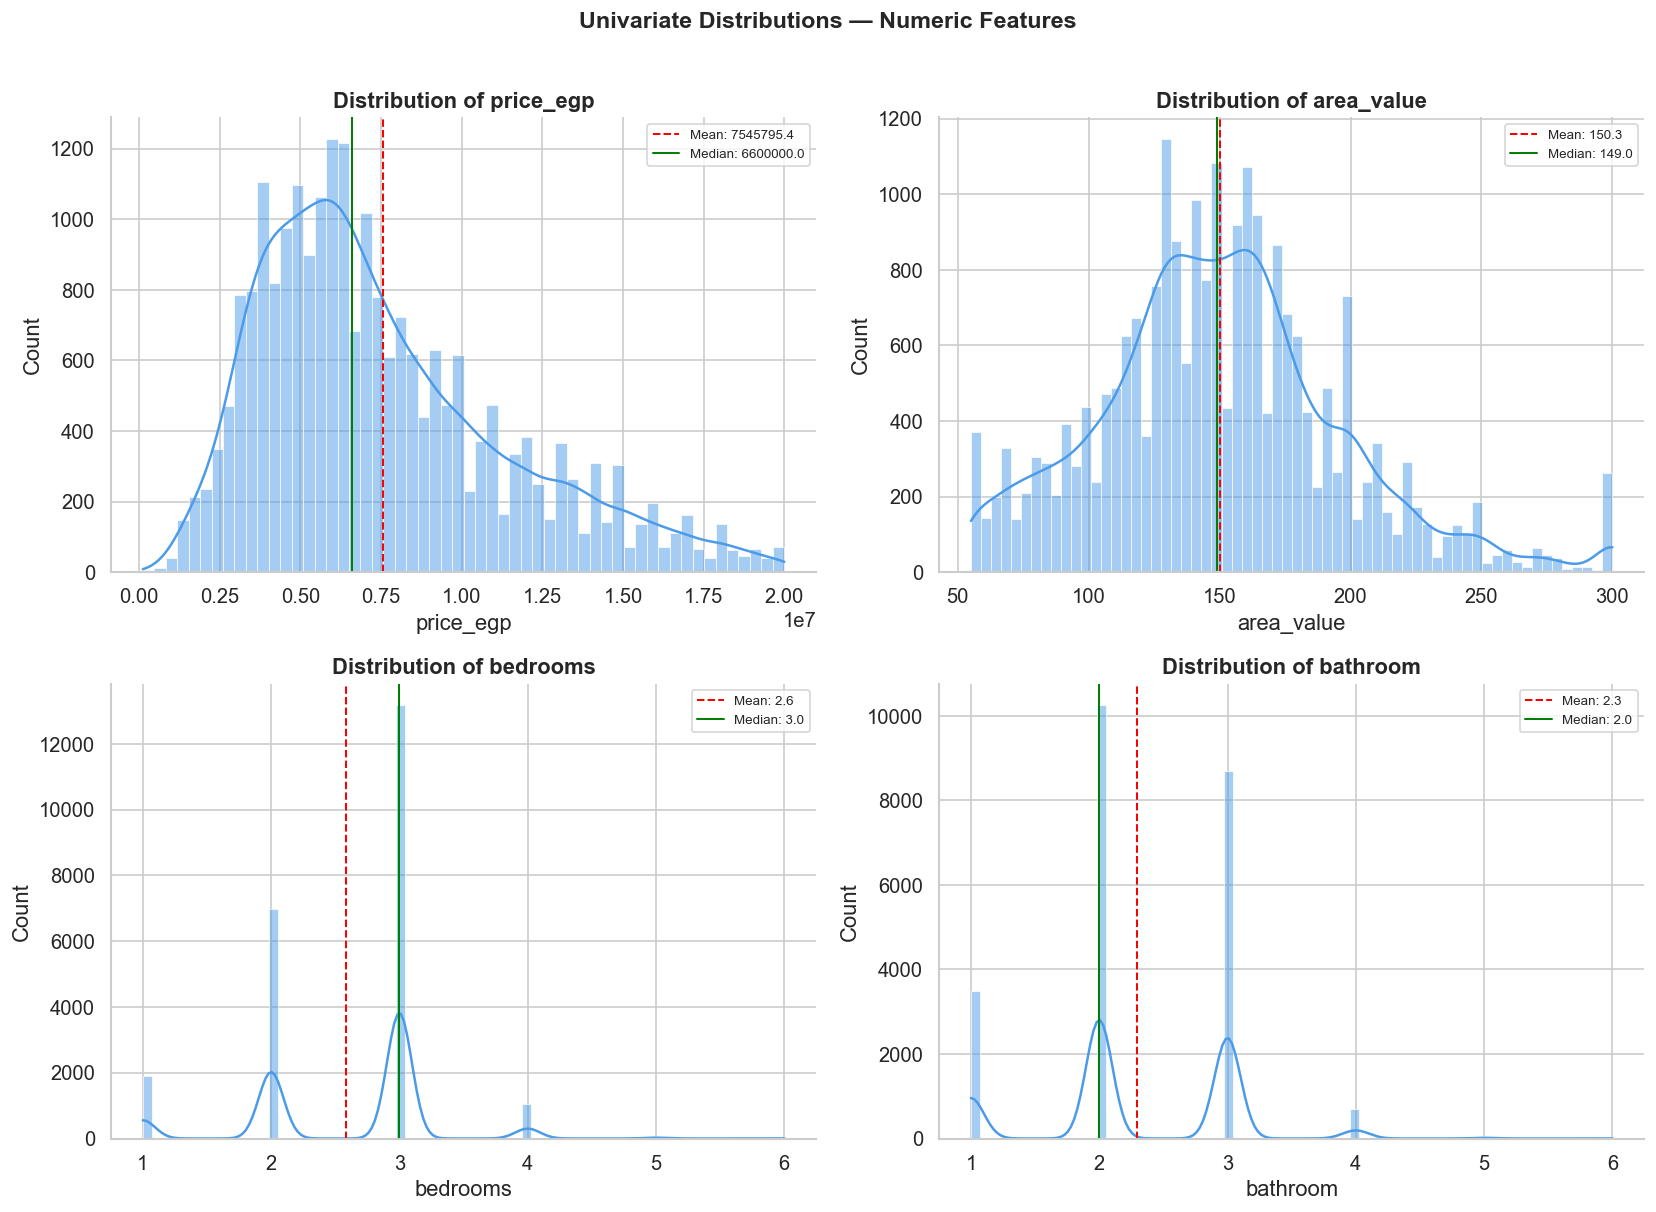

In [34]:
def plot_histogram_kde(
    df: pd.DataFrame,
    columns: list[str],
    n_cols: int = 2,
    figsize: tuple[int, int] = (14, 10),
    save_path: Path | None = None,
) -> None:
    """Plot histograms with KDE overlays for a list of numeric columns.

    Uses Freedman-Diaconis rule for bin width selection (from lecture):
        bin_width = 2 × IQR / n^(1/3)

    Args:
        df: Input DataFrame.
        columns: List of numeric column names to plot.
        n_cols: Number of subplot columns in the grid.
        figsize: Figure size tuple (width, height).
        save_path: If provided, saves the figure to this path.
    """
    n_rows = -(-len(columns) // n_cols)   # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        data = df[col].dropna()

        # Freedman-Diaconis bin count
        iqr = data.quantile(0.75) - data.quantile(0.25)
        bin_width = 2 * iqr / (len(data) ** (1 / 3)) if iqr > 0 else 1
        n_bins = max(10, int((data.max() - data.min()) / bin_width))

        sns.histplot(data, bins=n_bins, kde=True, ax=ax, color="#4C9BE8",
                     edgecolor="white", linewidth=0.4)
        ax.set_title(f"Distribution of {col}", fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

        # Annotate with mean and median
        ax.axvline(data.mean(), color="red",   linestyle="--", linewidth=1.2,
                   label=f"Mean: {data.mean():.1f}")
        ax.axvline(data.median(), color="green", linestyle="-",  linewidth=1.2,
                   label=f"Median: {data.median():.1f}")
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Univariate Distributions — Numeric Features",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_histogram_kde(
    df,
    columns=[*CONTINUOUS_FEATURES, *ORDINAL_FEATURES],
    save_path=FIGURES_PATH / "01_histograms_numeric.png",
)

## Insights
### price_egp
- The mean is higher than the median, there is right skew. This means most listings cluster at lower prices, but a long tail of expensive luxury properties pulls the mean upward. 
- The KDE curve confirms this: a steep rise on the left, a peak, then a slow decay to the right. This is called a log-normal distribution, it is very common for price data in real markets.

- Tree-based models (Random Forest, XGBoost) handle this naturally. Linear models and distance-based models (KNN, SVM) will be sensitive to this skew, a log transform of price_egp in the feature engineering phase would be helpful. 

### area_value
- Mean and median are almost identical, this distribution is almost symmetric, with only slight right skew. The peak is around 130–160 sqm, the standard Egyptian apartment size. There is a secondary peak around 200–220 sqm (larger units) and a thin right tail extending to ~310 sqm (large luxury apartments). This secondary hump makes the distribution slightly bimodal: two market segments (standard and large) coexisting.

- The near-symmetric distribution means area_value can be used without transformation for most models.

### bedrooms and bathrooms

- Both are discrete count variables, they can only take integer values, so the histogram shows sharp isolated spikes rather than a smooth distribution. This phenomenon is called multimodality in discrete data, each spike is a mode.

For bedrooms: 
- 2BR and 3BR dominate 
- 1BR is rare (studio/small market) 
- 4BR+ is very sparse, the long right tail 
- The mean (2.6) being below the median (3) reflects that the 2BR spike is very tall and slightly pulls the mean down


For bathrooms: 
- 2-bathroom listings dominate, followed by 3-bathroom. 
- 1-bathroom is rare (very small units)


### Box and Violin Plots for Continuous Features

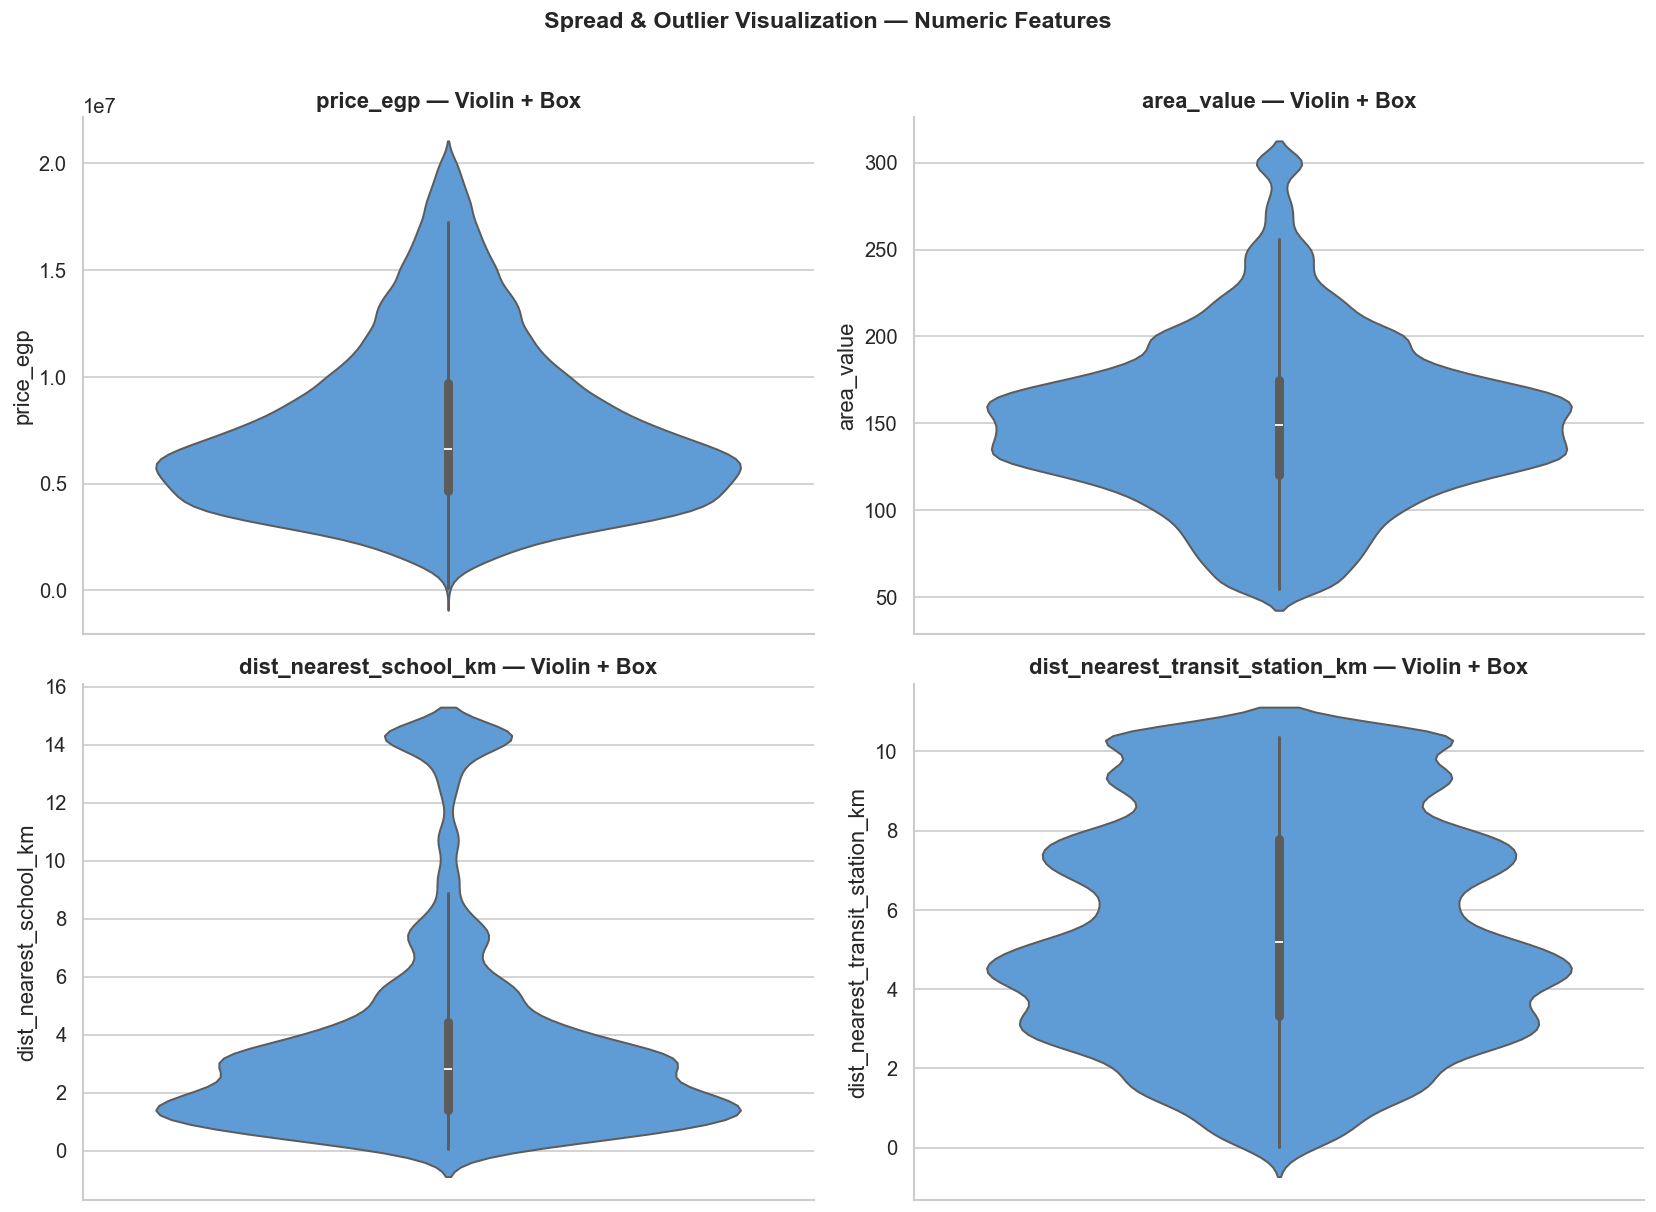

In [35]:
def plot_box_violin_grid(
    df: pd.DataFrame,
    columns: list[str],
    figsize: tuple[int, int] = (14, 10),
    save_path: Path | None = None,
) -> None:
    """Plot side-by-side box and violin plots for each numeric column.

    Shows both summary statistics (box) and distribution shape (violin)
    per the lecture: "a fancy version of box plots that also shows the KDE shape."

    Args:
        df: Input DataFrame.
        columns: List of numeric columns to plot.
        figsize: Figure size.
        save_path: Optional save path.
    """
    n_cols_grid = 2
    n_rows = -(-len(columns) // n_cols_grid)
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        data = df[[col]].dropna()

        # Left half: box plot, right half: violin — use twin-axis trick with inset
        # Simpler approach: violin with inner box
        sns.violinplot(y=data[col], ax=ax, color="#4C9BE8", inner="box",
                       linewidth=1.2)
        ax.set_title(f"{col} — Violin + Box", fontweight="bold")
        ax.set_ylabel(col)

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Spread & Outlier Visualization — Numeric Features",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_box_violin_grid(
    df,
    columns=CONTINUOUS_FEATURES + ["dist_nearest_school_km", "dist_nearest_transit_station_km"],
    save_path=FIGURES_PATH / "02_violin_box_numeric.png",
)

### price_egp
- The violin is pear-shaped, massively wide at the bottom (most listings are affordable) and very narrow at the top (few luxury listings)
- The embedded box shows the IQR (middle 50% of data) is relatively compact around 4–10M EGP, while the upper whisker and thin violin neck stretch all the way to 22M EGP. 
  
This confirms the right skew, and now we can also see the concentration of mass, almost 75% of all listings cost under ~10M EGP.

- Kurtosis: The pointed, peaked shape of the violin and the very long upper tail indicate high (leptokurtic) kurtosis, more values clustered near the center and more extreme outliers than a normal distribution would have Standard normal-assumption tests are inappropriate for this variable.

### area_value
- The violin is wider in the middle and tapers at both ends, more symmetric than price. Fairly concentrated distribution
- The box shows the IQR runs roughly from 120 to 180 sqm, an 80 sqm range that covers the bulk of Egyptian apartments

### dist_nearest_school_km
- Extremely narrow violin body with the mass concentrated near 0–2 km, and a very long thin upper tail reaching 50 km
- This is extreme right skew, most properties are close to a school, but a small minority of listings (probably in remote coastal or desert areas like North Coast) are very far away

### dist_nearest_transit_station_km
- bimodal, there are two clear bulges in the violin body, one around 0–2 km and another around 5–7 km
- This is an important pattern: one group of listings is in dense urban areas with transit nearby, a second group is in suburban or newer developments where transit is 5–8 km away. This bimodality is important.


### Bar Charts of Categorical Features

C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\2502266636.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, ax=ax,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\2502266636.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, ax=ax,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\2502266636.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, ax=ax,


C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\2502266636.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, ax=ax,


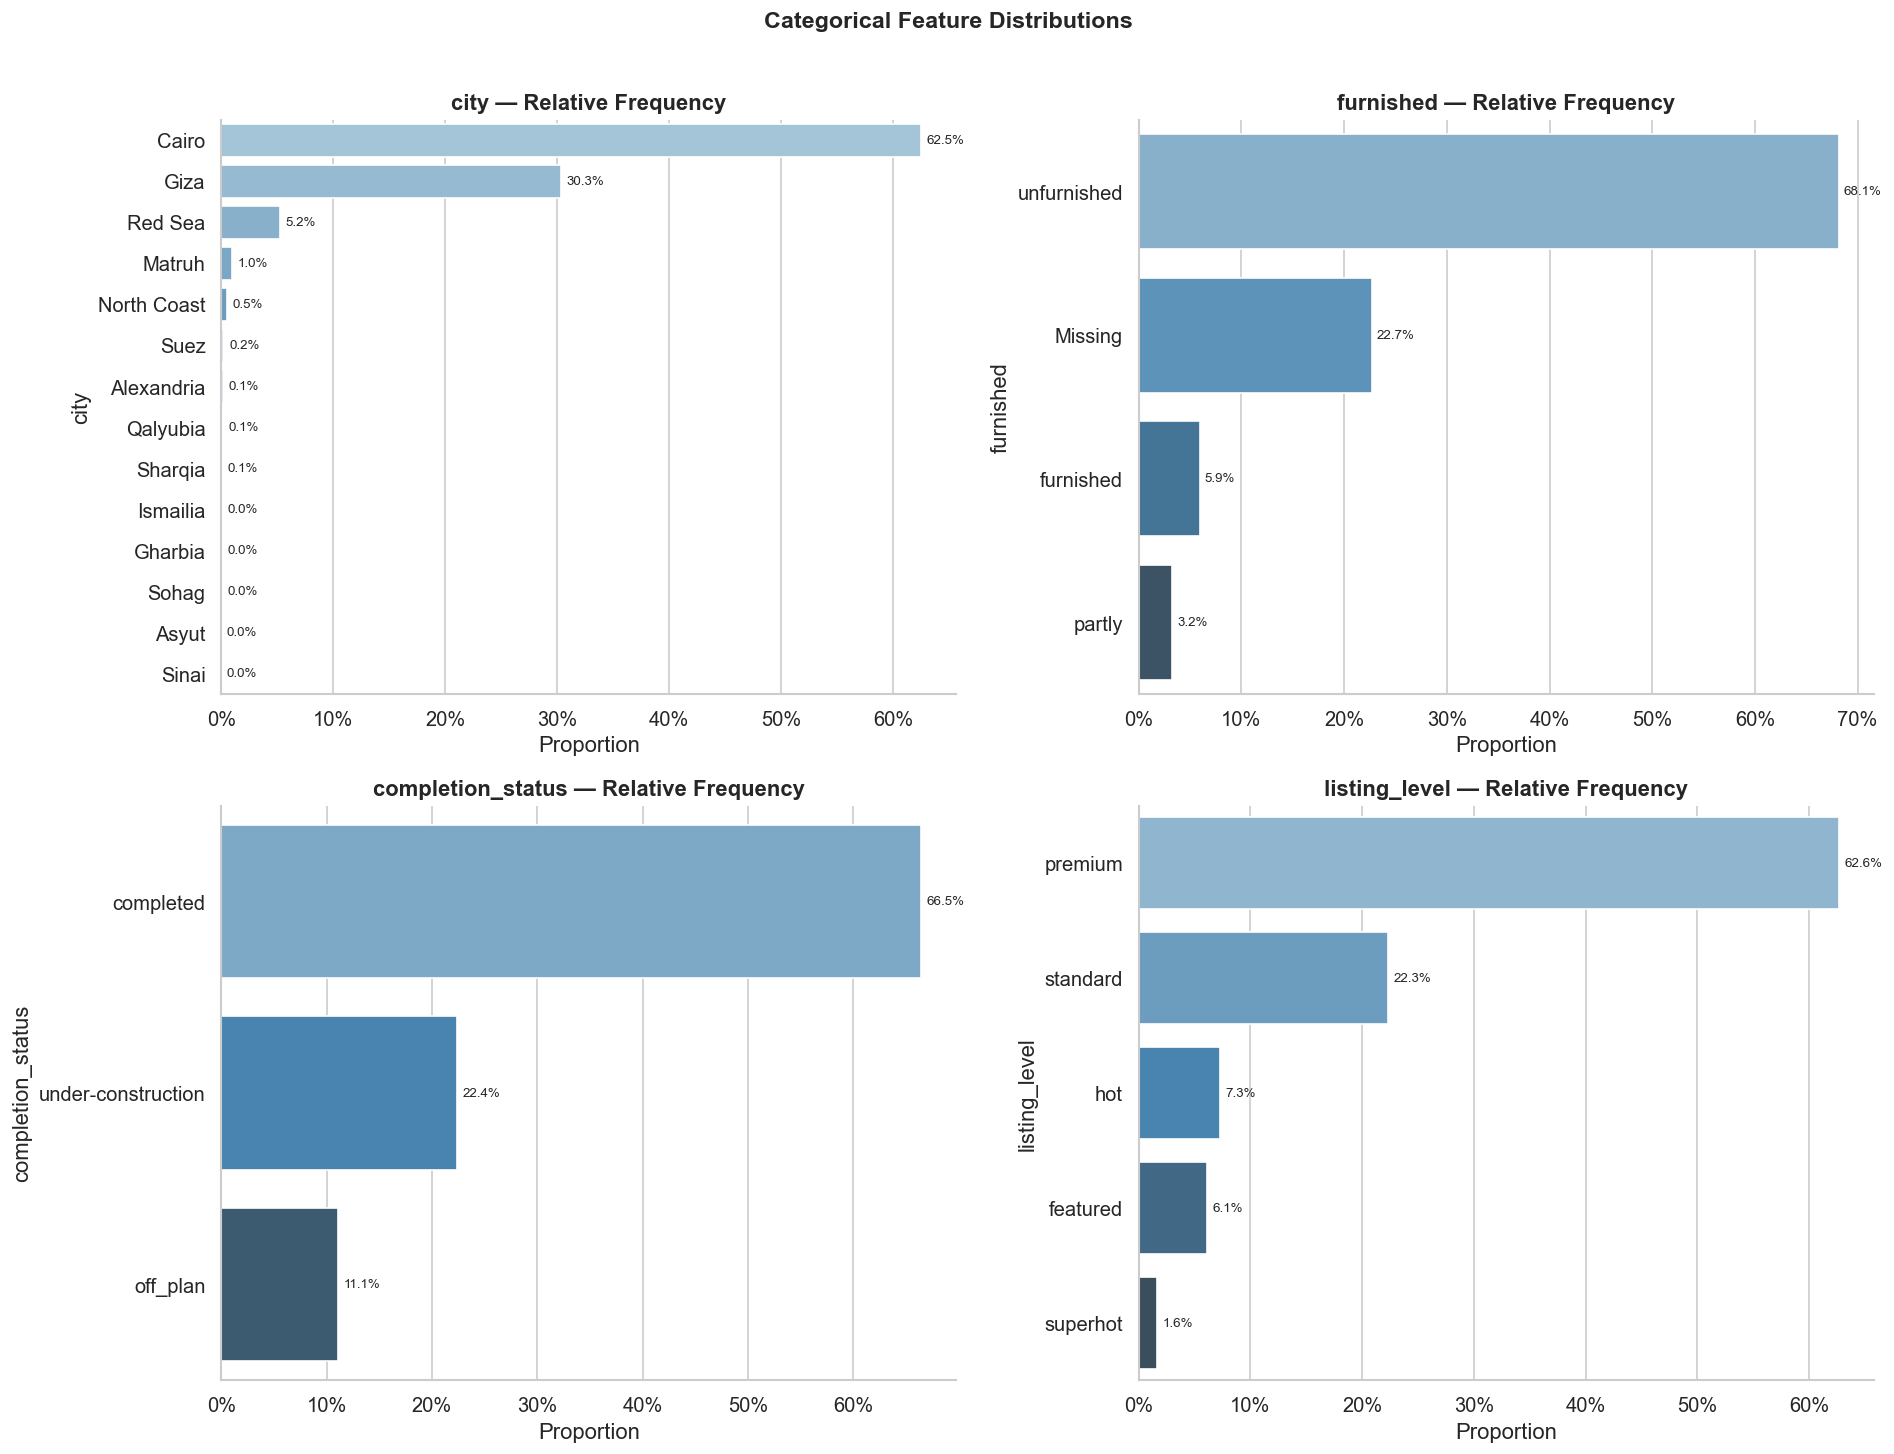

In [36]:
def plot_categorical_bar_charts(
    df: pd.DataFrame,
    columns: list[str],
    figsize: tuple[int, int] = (16, 12),
    top_n: int = 15,
    save_path: Path | None = None,
) -> None:
    """Plot bar charts showing relative frequency for categorical features.

    Uses relative frequency (proportion) rather than raw count so that
    different-cardinality features are visually comparable.

    Args:
        df: Input DataFrame.
        columns: Categorical column names to plot.
        figsize: Figure size.
        top_n: For high-cardinality columns, show only the top N categories.
        save_path: Optional save path.
    """
    n_cols_grid = 2
    n_rows = -(-len(columns) // n_cols_grid)
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        freq = df[col].value_counts(normalize=True).head(top_n)

        sns.barplot(x=freq.values, y=freq.index, ax=ax,
                    palette="Blues_d", orient="h")
        ax.set_title(f"{col} — Relative Frequency", fontweight="bold")
        ax.set_xlabel("Proportion")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

        # Annotate bars with percentage
        for bar, val in zip(ax.patches, freq.values):
            ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1%}", va="center", fontsize=8)

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Categorical Feature Distributions",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_categorical_bar_charts(
    df,
    columns=CATEGORICAL_FEATURES,
    save_path=FIGURES_PATH / "03_categorical_bars.png",
)

### city
- The dataset is heavily dominated by Cairo and Giza together
- All other cities Red Sea, Alexandria, Matruh, North Coast, and the rest are marginal in count 
  
A model trained on this data will be very well-calibrated for Cairo/Giza listings and may be unreliable for Red Sea or North Coast listings simply due to data volume. 

### furnished
- Nearly 70% of listings are unfurnished, this reflects the Egyptian market norm where buyers prefer to furnish themselves 
- The 22% missing category is from our cleaning decision to preserve informative missingness. 
- Truly furnished listings are rare at only 5.9%.

### completion_status
- 66.5% of listings are completed, ready properties
- 22.4% are under construction
- Off plan is the smallest category at 11%

### listing_level
- Premium: 62% of listings

### Target Column (Price Category) Distribution

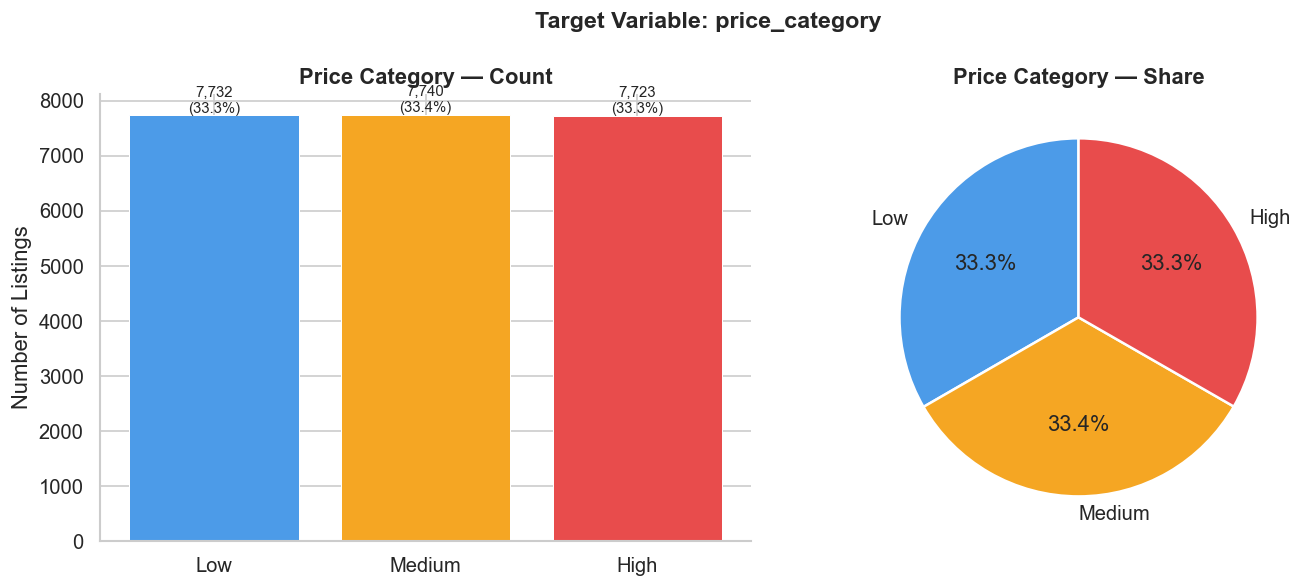

In [37]:
def plot_target_distribution(
    df: pd.DataFrame,
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    save_path: Path | None = None,
) -> None:
    """Plot bar chart and pie chart for the target variable distribution side by side.

    Args:
        df: Input DataFrame.
        target_col: Name of the target column.
        order: Ordered list of category labels.
        palette: Dict mapping category label to hex color.
        save_path: Optional save path.
    """
    counts = df[target_col].value_counts().reindex(order)
    colors = [palette[c] for c in order]

    fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart
    ax_bar.bar(order, counts.values, color=colors, edgecolor="white", linewidth=0.6)
    ax_bar.set_title("Price Category — Count", fontweight="bold")
    ax_bar.set_ylabel("Number of Listings")
    for bar, count in zip(ax_bar.patches, counts.values):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                    f"{count:,}\n({count/len(df):.1%})",
                    ha="center", fontsize=9)

    # Pie chart
    ax_pie.pie(counts.values, labels=order, colors=colors,
               autopct="%1.1f%%", startangle=90,
               wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    ax_pie.set_title("Price Category — Share", fontweight="bold")

    plt.suptitle("Target Variable: price_category",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_target_distribution(
    df, TARGET_COL, TARGET_ORDER, CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "04_target_distribution.png",
)

### Summary of Univariate Analysis

In [38]:
def compute_univariate_summary(
    df: pd.DataFrame,
    numeric_cols: list[str],
) -> pd.DataFrame:
    """Compute a descriptive statistics summary for numeric features.

    Includes: count, mean, median, std, skewness, kurtosis, min, max.

    Args:
        df: Input DataFrame.
        numeric_cols: List of numeric column names.

    Returns:
        DataFrame with one row per feature and summary statistic columns.
    """
    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        rows.append({
            "feature":  col,
            "count":    int(s.count()),
            "mean":     s.mean(),
            "median":   s.median(),
            "std":      s.std(),
            "skewness": s.skew(),
            "kurtosis": s.kurt(),
            "min":      s.min(),
            "max":      s.max(),
        })
    return pd.DataFrame(rows).set_index("feature").round(3)


summary_table = compute_univariate_summary(df, CONTINUOUS_FEATURES + POI_DISTANCE_COLS)
print("Univariate Summary — Numeric Features:")
summary_table

Univariate Summary — Numeric Features:


,count,mean,median,std,skewness,kurtosis,min,max
feature,,,,,,,,
price_egp,23195,7545795.394,6600000.000,3893828.490,0.916,0.342,113116.000,2.000000e+07
area_value,23195,150.285,149.000,46.686,0.471,0.597,55.000,3.000000e+02
dist_nearest_school_km,23195,3.758,2.806,3.561,1.814,2.657,0.062,1.434300e+01
dist_nearest_hospital_km,23195,5.183,3.770,4.797,1.457,1.436,0.029,1.872300e+01
dist_nearest_supermarket_km,23195,3.328,1.962,3.406,1.635,1.950,0.009,1.320500e+01
dist_nearest_mall_km,23195,4.957,4.820,2.841,0.485,-0.597,0.066,1.102200e+01
dist_nearest_transit_station_km,23195,5.512,5.191,2.769,0.114,-0.993,0.013,1.037800e+01
dist_nearest_cafe_restaurant_km,23195,2.562,1.606,2.587,1.713,2.309,0.002,1.028200e+01


## Bivariate Analysis: Feature vs. Target

### Box Plots Showing Continuous Features vs. Target

C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\3780754161.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feat, order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\3780754161.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feat, order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\3780754161.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feat, order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\3780754161.py:3

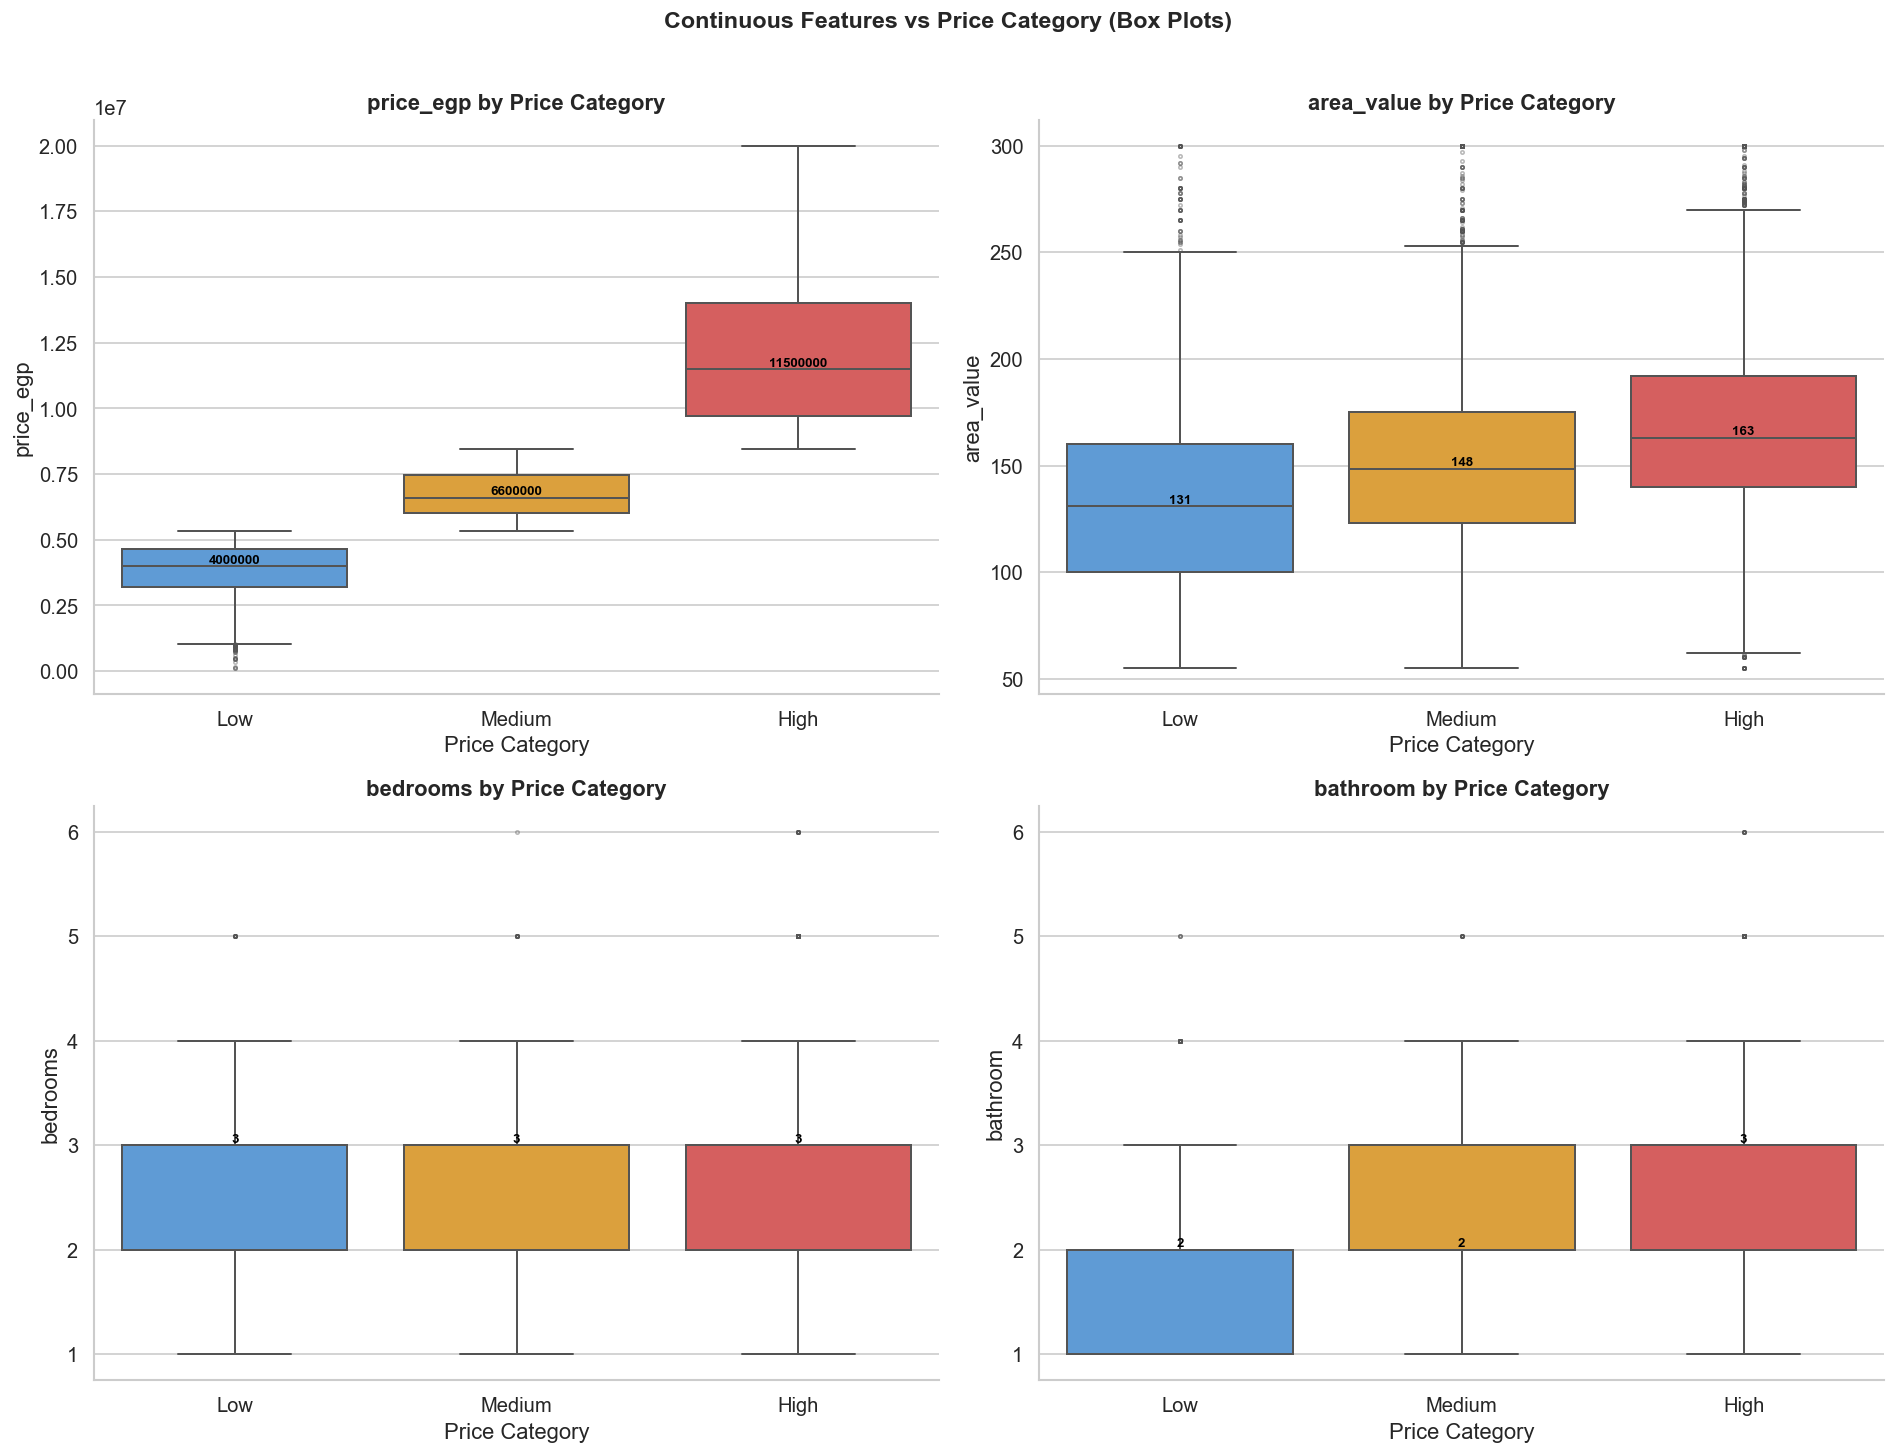

In [39]:
def plot_continuous_vs_target_boxplots(
    df: pd.DataFrame,
    features: list[str],
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    figsize: tuple[int, int] = (16, 12),
    save_path: Path | None = None,
) -> None:
    """Plot box plots for continuous features grouped by price category.

    This is the primary feature-to-target analysis for continuous variables,
    showing median, IQR, and outliers per price tier.

    Args:
        df: Input DataFrame.
        features: Continuous feature column names.
        target_col: Target column name.
        order: Ordered list of target category labels.
        palette: Dict mapping category to color.
        figsize: Figure size.
        save_path: Optional save path.
    """
    n_cols_grid = 2
    n_rows = -(-len(features) // n_cols_grid)
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=figsize)
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(data=df, x=target_col, y=feat, order=order,
                    palette=palette, ax=ax, linewidth=1.2,
                    flierprops={"marker": "o", "markersize": 2, "alpha": 0.4})
        ax.set_title(f"{feat} by Price Category", fontweight="bold")
        ax.set_xlabel("Price Category")

        # Annotate with median value per group
        for j, cat in enumerate(order):
            median_val = df[df[target_col] == cat][feat].median()
            ax.text(j, median_val, f"{median_val:.0f}",
                    ha="center", va="bottom", fontsize=8,
                    color="black", fontweight="bold")

    for k in range(len(features), len(axes)):
        axes[k].set_visible(False)

    plt.suptitle("Continuous Features vs Price Category (Box Plots)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_continuous_vs_target_boxplots(
    df,
    features=[*CONTINUOUS_FEATURES, *ORDINAL_FEATURES],
    target_col=TARGET_COL,
    order=TARGET_ORDER,
    palette=CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "05_boxplots_vs_target.png",
)

### price_egp by tier
- The three boxes are non-overlapping 

### area_value by tier
- Low: 131 sqm, Medium: 148 sqm, High: 163 sqm median
- The medians increase monotonically from Low to High, meaning that larger apartments cost more
- However, the boxes overlap significantly. There are Low-tier listings with 200+ sqm area and High-tier listings with 100 sqm area. This tells us that area alone cannot classify price tier. A 150 sqm apartment could be Low, Medium, or High depending on other factors (location, amenities, city). Area is a moderately useful feature but insufficient on its own.

### bedrooms and bathrooms by tier
- All three price tiers share median of 3 bedrooms and 2–3 bathrooms
  
implication: bedrooms and bathrooms (in isolation) are very weak discriminators for price tier.

### Strip Plots of POI (Point Of Interest) Distance Features

C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\910683008.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sample, x=target_col, y=col, order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\910683008.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sample, x=target_col, y=col, order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\910683008.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sample, x=target_col, y=col, order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\910

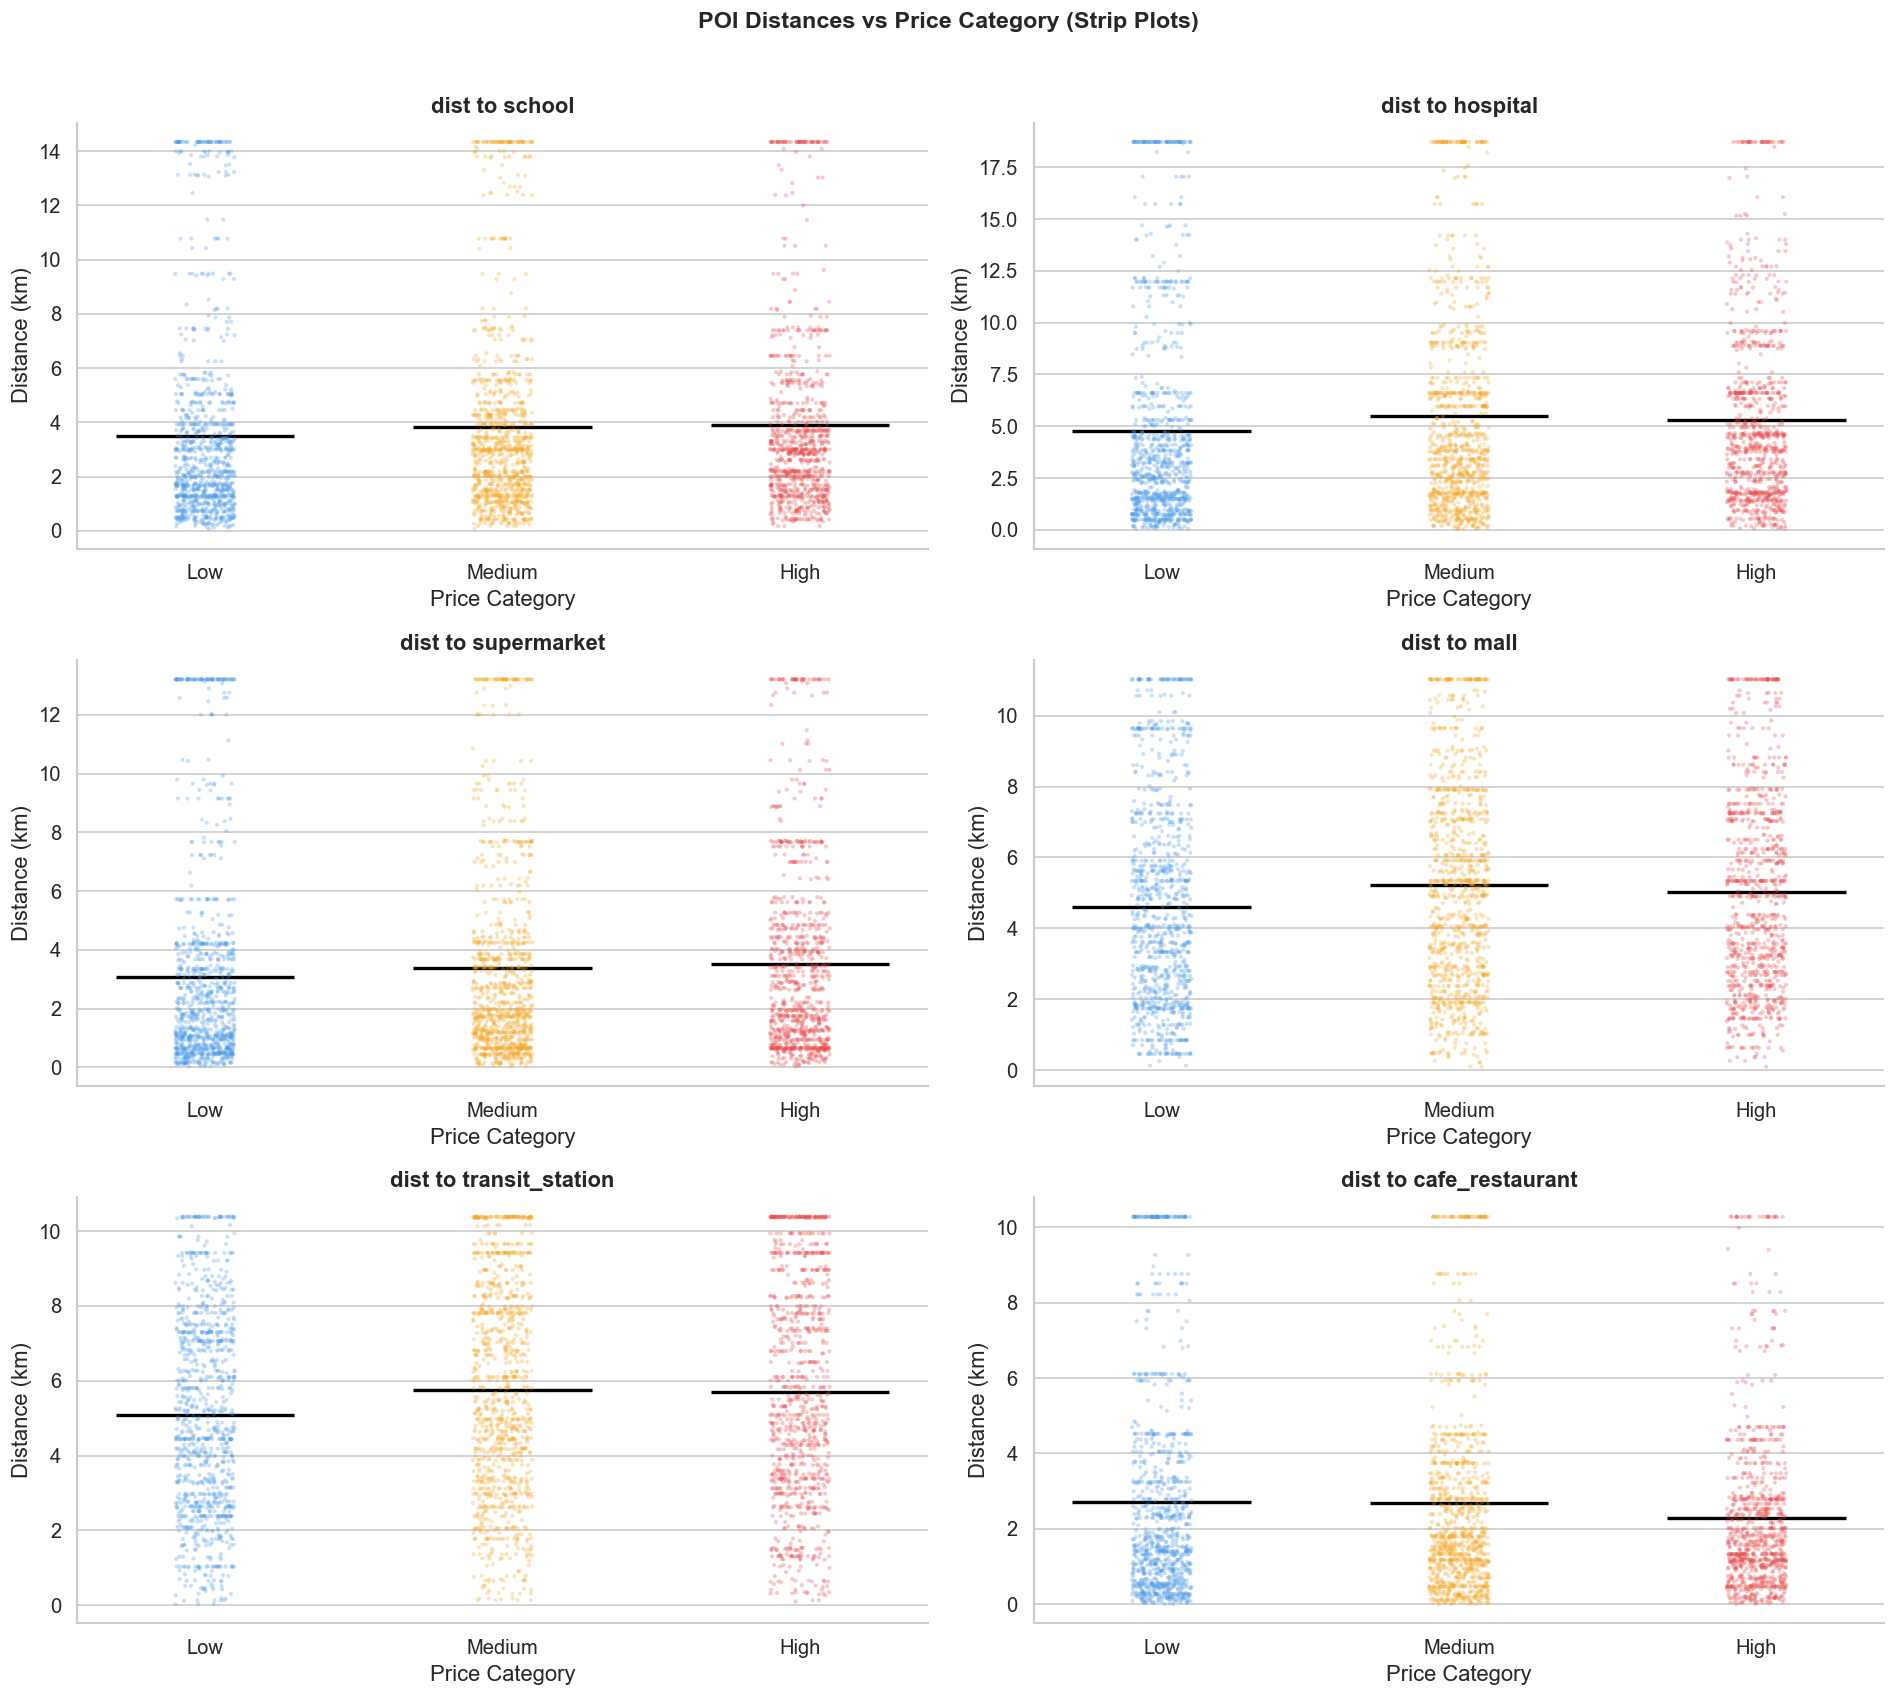

In [40]:
def plot_strip_plots_poi(
    df: pd.DataFrame,
    poi_cols: list[str],
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    figsize: tuple[int, int] = (16, 14),
    save_path: Path | None = None,
) -> None:
    """Plot strip plots for POI distance features grouped by price category.

    Strip plots are ideal for bounded continuous features where you want to
    see the actual point distribution, not just summary statistics.

    Args:
        df: Input DataFrame.
        poi_cols: POI distance column names.
        target_col: Target column name.
        order: Category order.
        palette: Color palette dict.
        figsize: Figure size.
        save_path: Optional save path.
    """
    n_cols_grid = 2
    n_rows = -(-len(poi_cols) // n_cols_grid)
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(poi_cols):
        ax = axes[i]
        # Use a sample for performance — strip plots with 30k points are slow
        sample = df.sample(n=min(3000, len(df)), random_state=42)
        sns.stripplot(data=sample, x=target_col, y=col, order=order,
                      palette=palette, ax=ax, alpha=0.3, size=2.5, jitter=True)
        # Overlay mean per group as a horizontal line
        for j, cat in enumerate(order):
            mean_val = df[df[target_col] == cat][col].mean()
            ax.hlines(mean_val, j - 0.3, j + 0.3,
                      color="black", linewidth=2, label="mean" if j == 0 else "")
        short_name = col.replace("dist_nearest_", "").replace("_km", "")
        ax.set_title(f"dist to {short_name}", fontweight="bold")
        ax.set_xlabel("Price Category")
        ax.set_ylabel("Distance (km)")

    for k in range(len(poi_cols), len(axes)):
        axes[k].set_visible(False)

    plt.suptitle("POI Distances vs Price Category (Strip Plots)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_strip_plots_poi(
    df,
    poi_cols=POI_DISTANCE_COLS,
    target_col=TARGET_COL,
    order=TARGET_ORDER,
    palette=CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "07_strip_poi_vs_target.png",
)

### POI Distances vs Price Category 
The black line is the group mean, the most important element.

The most striking finding is how little the means differ across Low, Medium, and High tiers for most POI types. This is a critical insight: proximity to amenities does not cleanly separate price tiers the way area_value or city does.

### Bar Charts Showing Categorical Features vs. Target

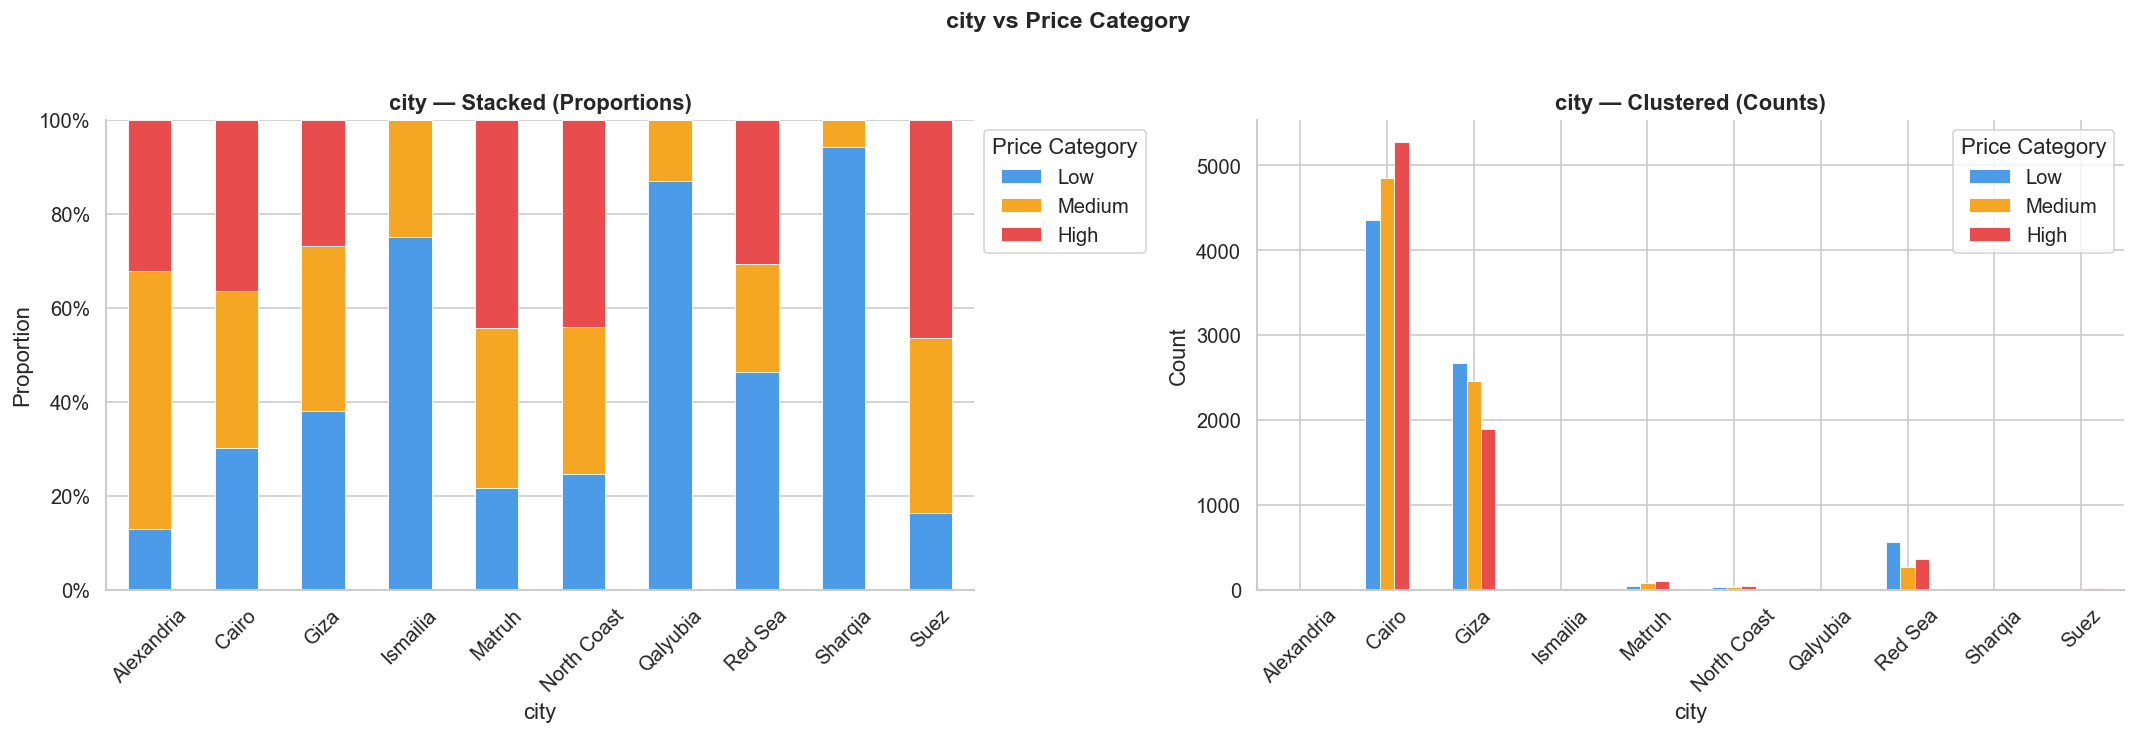

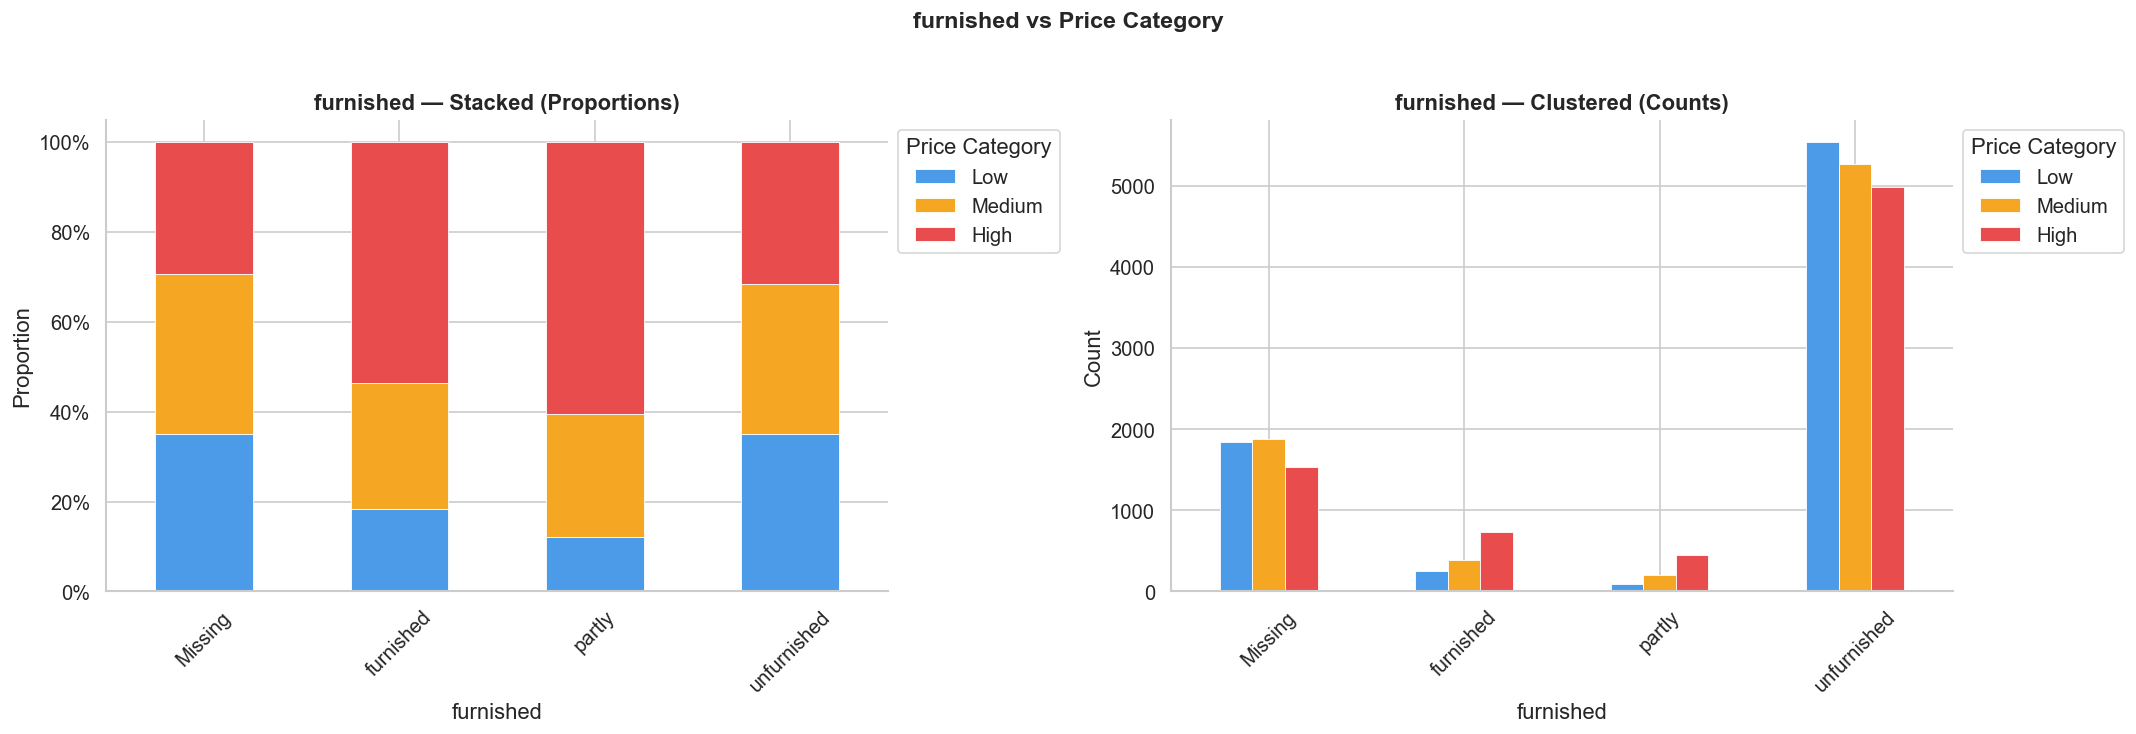

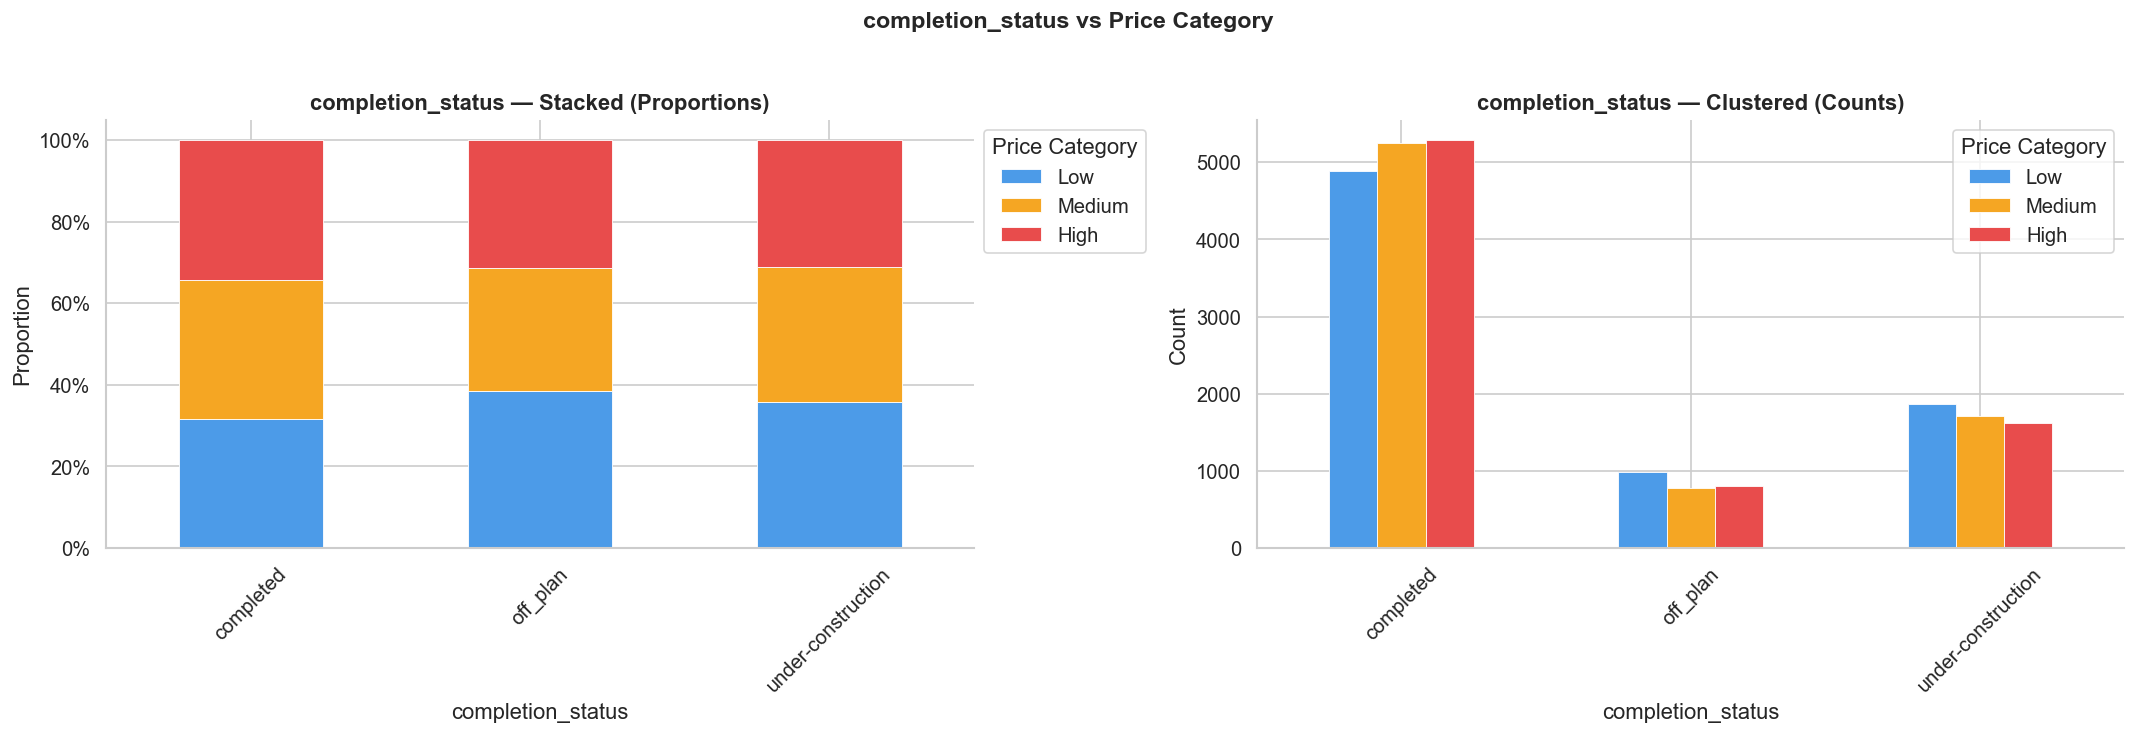

In [41]:
def plot_stacked_and_clustered_bars(
    df: pd.DataFrame,
    feature: str,
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    top_n: int = 10,
    save_path: Path | None = None,
) -> None:
    """Plot stacked and clustered bar charts for a categorical feature vs target.

    Stacked: easier to read tier proportions within each category.
    Clustered: easier to compare absolute counts across tiers.

    Args:
        df: Input DataFrame.
        feature: Categorical feature column name.
        target_col: Target column name.
        order: Ordered list of target labels.
        palette: Color palette dict.
        top_n: Show only the top N categories by listing count.
        save_path: Optional save path.
    """
    top_cats = df[feature].value_counts().head(top_n).index
    plot_df = df[df[feature].isin(top_cats)]

    # Build crosstab normalized by row (proportion per feature value)
    ct_norm = pd.crosstab(plot_df[feature], plot_df[target_col], normalize="index")[order]
    ct_abs  = pd.crosstab(plot_df[feature], plot_df[target_col])[order]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Stacked bar
    ct_norm.plot(kind="bar", stacked=True, ax=ax1,
                 color=[palette[c] for c in order], edgecolor="white",
                 linewidth=0.5)
    ax1.set_title(f"{feature} — Stacked (Proportions)", fontweight="bold")
    ax1.set_xlabel(feature)
    ax1.set_ylabel("Proportion")
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax1.legend(title="Price Category", bbox_to_anchor=(1, 1))
    ax1.tick_params(axis="x", rotation=45)

    # Clustered bar
    ct_abs.plot(kind="bar", stacked=False, ax=ax2,
                color=[palette[c] for c in order], edgecolor="white",
                linewidth=0.5)
    ax2.set_title(f"{feature} — Clustered (Counts)", fontweight="bold")
    ax2.set_xlabel(feature)
    ax2.set_ylabel("Count")
    ax2.legend(title="Price Category", bbox_to_anchor=(1, 1))
    ax2.tick_params(axis="x", rotation=45)

    plt.suptitle(f"{feature} vs Price Category",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


# Run for the most important categorical features
for feat, fname in [
    ("city",               "08a_city_vs_target"),
    ("furnished",          "08b_furnished_vs_target"),
    ("completion_status",  "08c_completion_vs_target"),
]:
    plot_stacked_and_clustered_bars(
        df, feature=feat, target_col=TARGET_COL,
        order=TARGET_ORDER, palette=CATEGORY_PALETTE,
        save_path=FIGURES_PATH / f"{fname}.png",
    )

### City vs. Price Category:

It is clear that city is a powerful categorical variable. The variation is enormous.

But we can see in the clustered chart that Cairo and Giza completely dominate in absolute count. All other cities are so small in count that the model will have very limited data to learn their price patterns.

### Furnished vs. Price Category:

The contrast between Furnished/PARTLY (~55–58% High) and Unfurnished (~30% High) is very strong. Furnished and PARTLY-furnished listings are nearly twice as likely to be High tier as Unfurnished.

But despite the strong proportional signal, the absolute counts show a big imbalance in counts.

### Completion Status vs. Price Category:

The 3 completion statuses have very similar distributions.

### Heat Map of City vs. Target (Price Category)

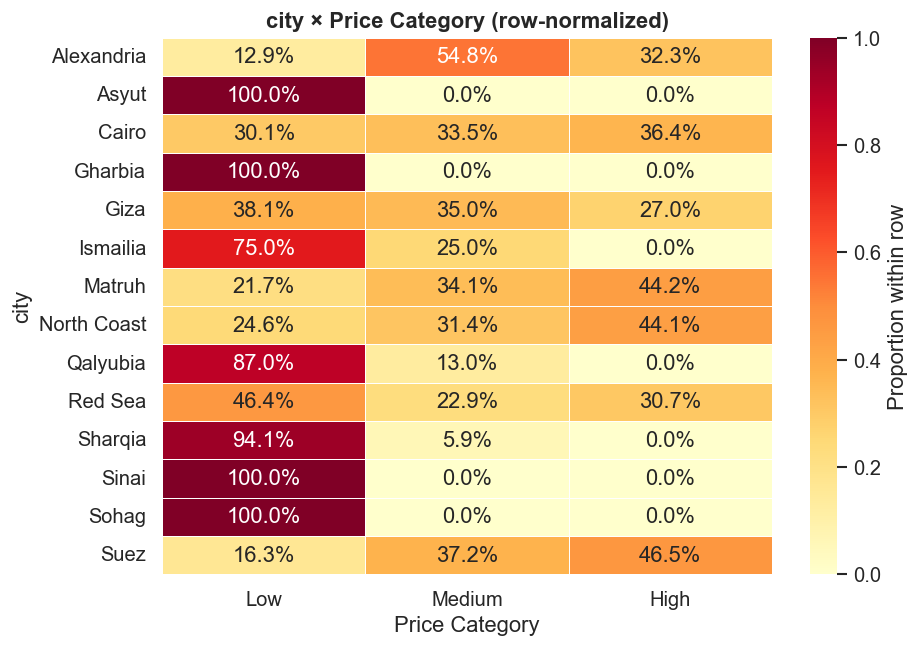

In [42]:
def plot_crosstab_heatmap(
    df: pd.DataFrame,
    feature: str,
    target_col: str,
    order: list[str],
    normalize: str = "index",
    top_n: int = 15,
    save_path: Path | None = None,
) -> None:
    """Plot a heatmap of a crosstab between a categorical feature and the target.

    Args:
        df: Input DataFrame.
        feature: Categorical feature column name.
        target_col: Target column name.
        order: Target category order.
        normalize: How to normalize: 'index' (by row), 'columns', or None.
        top_n: Show top N categories by count.
        save_path: Optional save path.
    """
    top_cats = df[feature].value_counts().head(top_n).index
    ct = pd.crosstab(
        df[df[feature].isin(top_cats)][feature],
        df[df[feature].isin(top_cats)][target_col],
        normalize=normalize,
    )[order]

    fig, ax = plt.subplots(figsize=(8, max(4, len(ct) * 0.4)))
    sns.heatmap(
        ct, annot=True, fmt=".1%", cmap="YlOrRd",
        ax=ax, linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Proportion within row"},
    )
    ax.set_title(f"{feature} × Price Category (row-normalized)",
                 fontweight="bold")
    ax.set_xlabel("Price Category")
    ax.set_ylabel(feature)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_crosstab_heatmap(
    df, feature="city", target_col=TARGET_COL,
    order=TARGET_ORDER,
    save_path=FIGURES_PATH / "09_city_target_heatmap.png",
)

### High-tier cities (orange/yellow in the High column):

- North Coast 
- Matruh
- Suez, the highest

Balanced cities:

Cairo and Giza are very balanced.

### Low-tier dominated cities:

- Gharbia: 100% Low, every single listing is Low tier
- Sohag: 100% Low 
- Sharqia: 94% Low
- Qalyubia: 87% Low

The heatmap reveals a clear geographic price gradient: 
- coastal/resort cities (North Coast, Matruh, Suez) → High tier 
- Major urban centers (Cairo, Giza, Alexandria) → mixed 
- Delta/Upper Egypt (Gharbia, Sharqia, Sohag, Qalyubia) → Low tier

## Bivariate Analysis: Feature vs. Feature

### Scatter Plot Showing Area vs. Price

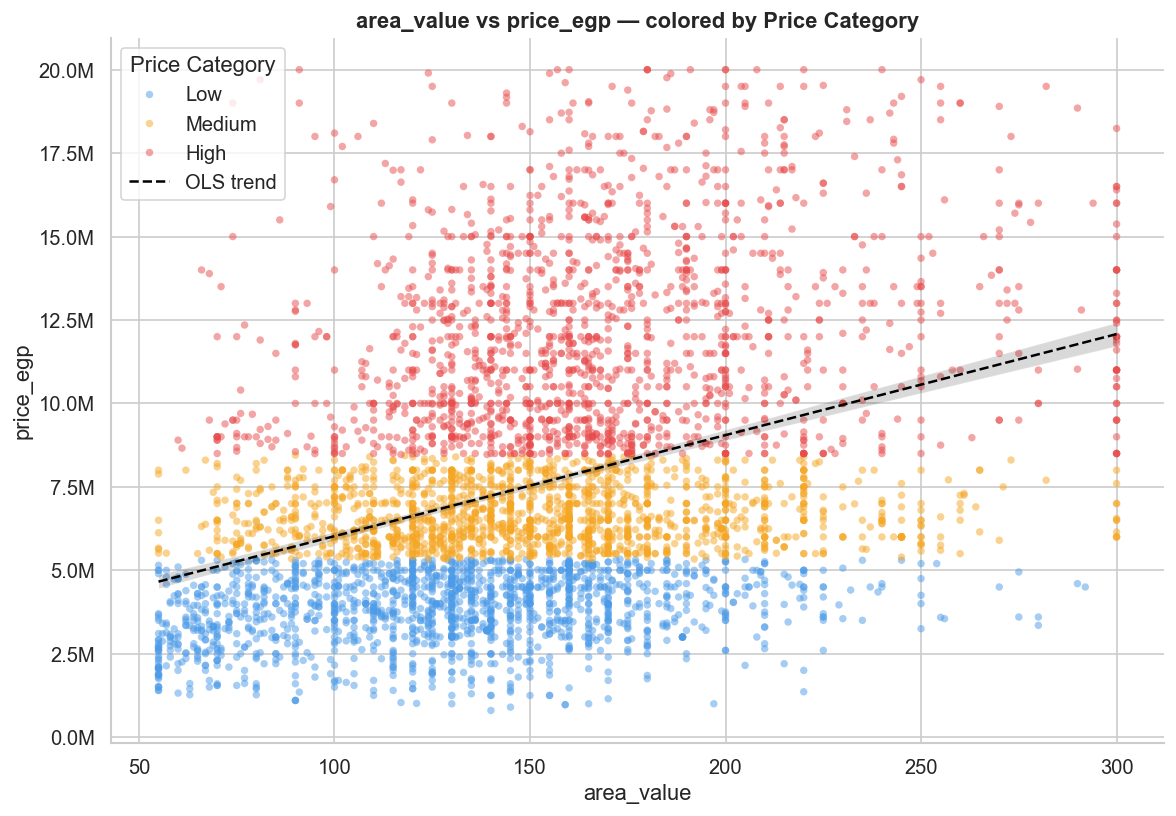

In [43]:
def plot_scatter_with_regression(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    hue_col: str,
    order: list[str],
    palette: dict[str, str],
    sample_n: int = 5000,
    save_path: Path | None = None,
) -> None:
    """Plot a scatter plot with regression line, colored by price category.

    Uses a sample for performance while preserving proportional representation
    across all three tiers.

    Args:
        df: Input DataFrame.
        x_col: X-axis column name.
        y_col: Y-axis column name.
        hue_col: Column to use for color (target).
        order: Category order for legend.
        palette: Color palette dict.
        sample_n: Max number of points to plot.
        save_path: Optional save path.
    """
    # Stratified sample: equal proportion from each tier
    sample_parts = []
    for _, group in df.groupby(hue_col, observed=True):
        sample_parts.append(
            group.sample(n=min(sample_n // 3, len(group)), random_state=42)
        )
    sample = pd.concat(sample_parts, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(data=sample, x=x_col, y=y_col, hue=hue_col,
                    hue_order=order, palette=palette, alpha=0.5,
                    s=20, ax=ax, linewidth=0)

    # Overall regression line (ignoring category)
    sns.regplot(data=sample, x=x_col, y=y_col, scatter=False,
                ax=ax, color="black", line_kws={"linewidth": 1.5, "linestyle": "--"},
                label="OLS trend")

    ax.set_title(f"{x_col} vs {y_col} — colored by Price Category",
                 fontweight="bold")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )
    ax.legend(title="Price Category")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_scatter_with_regression(
    df, x_col="area_value", y_col="price_egp",
    hue_col=TARGET_COL, order=TARGET_ORDER, palette=CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "10_area_vs_price_scatter.png",
)

The positive slope confirms that larger area correponds to a higher price, as expected. However, the slope is not steep, the enormous vertical scatter around the line (especially for High tier) means area alone is a weak price predictor. A 150 sqm apartment can be anywhere from 2M to 22M EGP depending on other factors.

### Hexbin Density Plot of Distance To Nearest Transit vs. Price

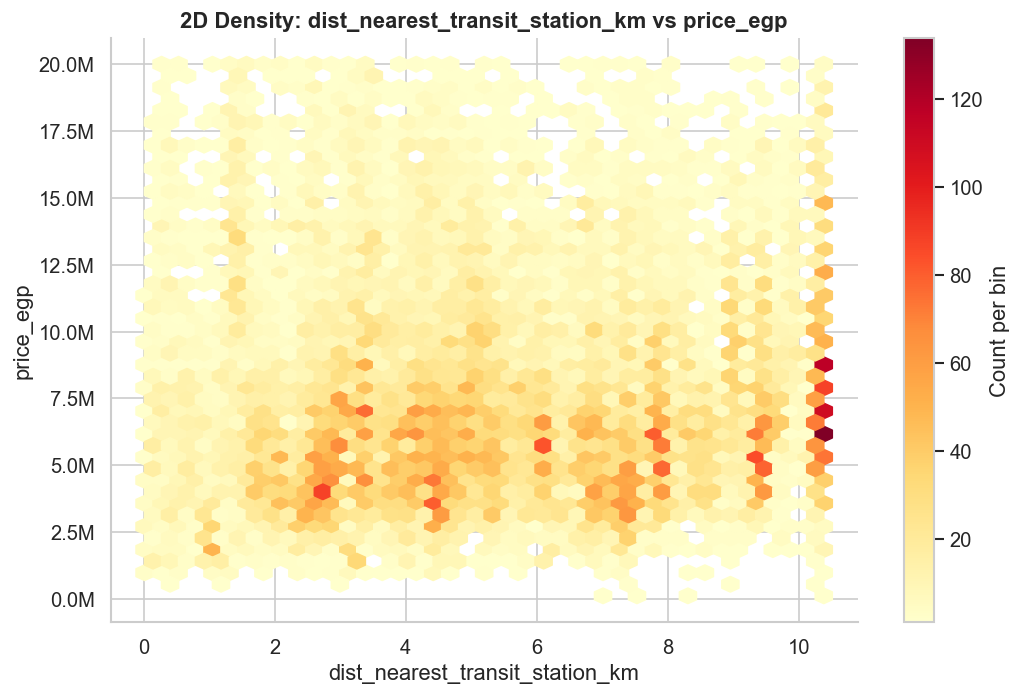

In [44]:
def plot_hexbin_density(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    gridsize: int = 40,
    save_path: Path | None = None,
) -> None:
    """Plot a hexbin 2D density chart for two continuous variables.

    Hexbin is preferred over scatter when the number of points is large
    and overplotting obscures the density pattern.

    Args:
        df: Input DataFrame.
        x_col: X-axis column name.
        y_col: Y-axis column name.
        gridsize: Resolution of hexagonal bins.
        save_path: Optional save path.
    """
    clean = df[[x_col, y_col]].dropna()

    fig, ax = plt.subplots(figsize=(9, 6))
    hb = ax.hexbin(clean[x_col], clean[y_col],
                   gridsize=gridsize, cmap="YlOrRd", mincnt=1)
    plt.colorbar(hb, ax=ax, label="Count per bin")
    ax.set_title(f"2D Density: {x_col} vs {y_col}", fontweight="bold")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_hexbin_density(
    df,
    x_col="dist_nearest_transit_station_km",
    y_col="price_egp",
    save_path=FIGURES_PATH / "11_hexbin_transit_vs_price.png",
)

The color scale shows count per hexagonal bin
- dark red = many listings in that zone
- pale yellow = few listings in that zone

the core zone with many listings spans 2.5M-9M in price. They range in distance to transit anywhere from 2 to 10 km.

### Categorical Heatmap of Completion Status and Furnished/Unfurnished

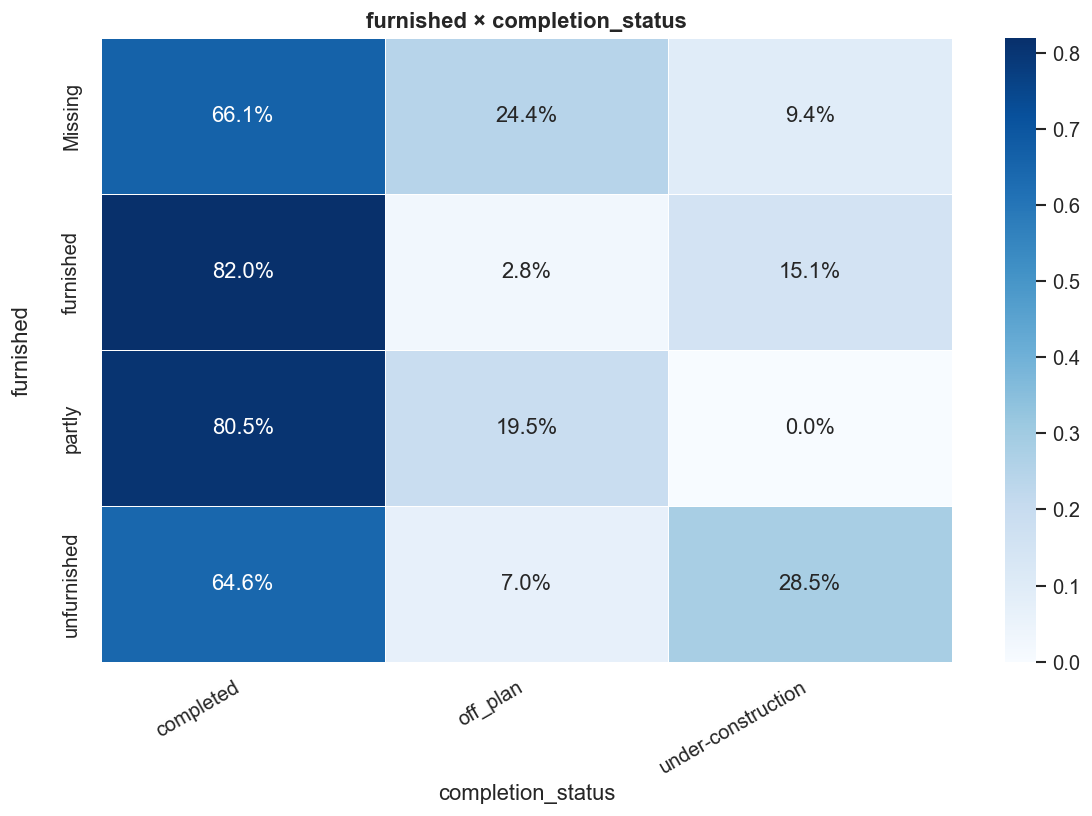

In [45]:
def plot_two_categorical_heatmap(
    df: pd.DataFrame,
    row_col: str,
    col_col: str,
    normalize: str = "index",
    save_path: Path | None = None,
) -> None:
    """Plot a heatmap of the crosstab between two categorical features.

    Args:
        df: Input DataFrame.
        row_col: Row variable column name.
        col_col: Column variable column name.
        normalize: Normalization direction: 'index', 'columns', or None.
        save_path: Optional save path.
    """
    ct = pd.crosstab(df[row_col], df[col_col], normalize=normalize)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(ct, annot=True, fmt=".1%", cmap="Blues",
                ax=ax, linewidths=0.5, linecolor="white")
    ax.set_title(f"{row_col} × {col_col}", fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_ylabel(row_col, labelpad=18)
    ax.tick_params(axis="y", pad=6)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_two_categorical_heatmap(
    df,
    row_col="furnished",
    col_col="completion_status",
    save_path=FIGURES_PATH / "12_furnished_completion_heatmap.png",
)

- Furnished: The overwhelming majority of furnished listings are in ready/completed properties. This makes sense.
  
- PARTLY: similar to furnished, with more off_plan than under_construction
  
- Unfurnished: Unfurnished listings are the dominant category for under-construction properties, which is expected. Buyers of incomplete properties buy unfurnished and furnish later.
 
-> key insight: a listing that is both Furnished and completed is likely High tier.


## Multivariate Analysis

### Correlation Matrix of Numeric Features

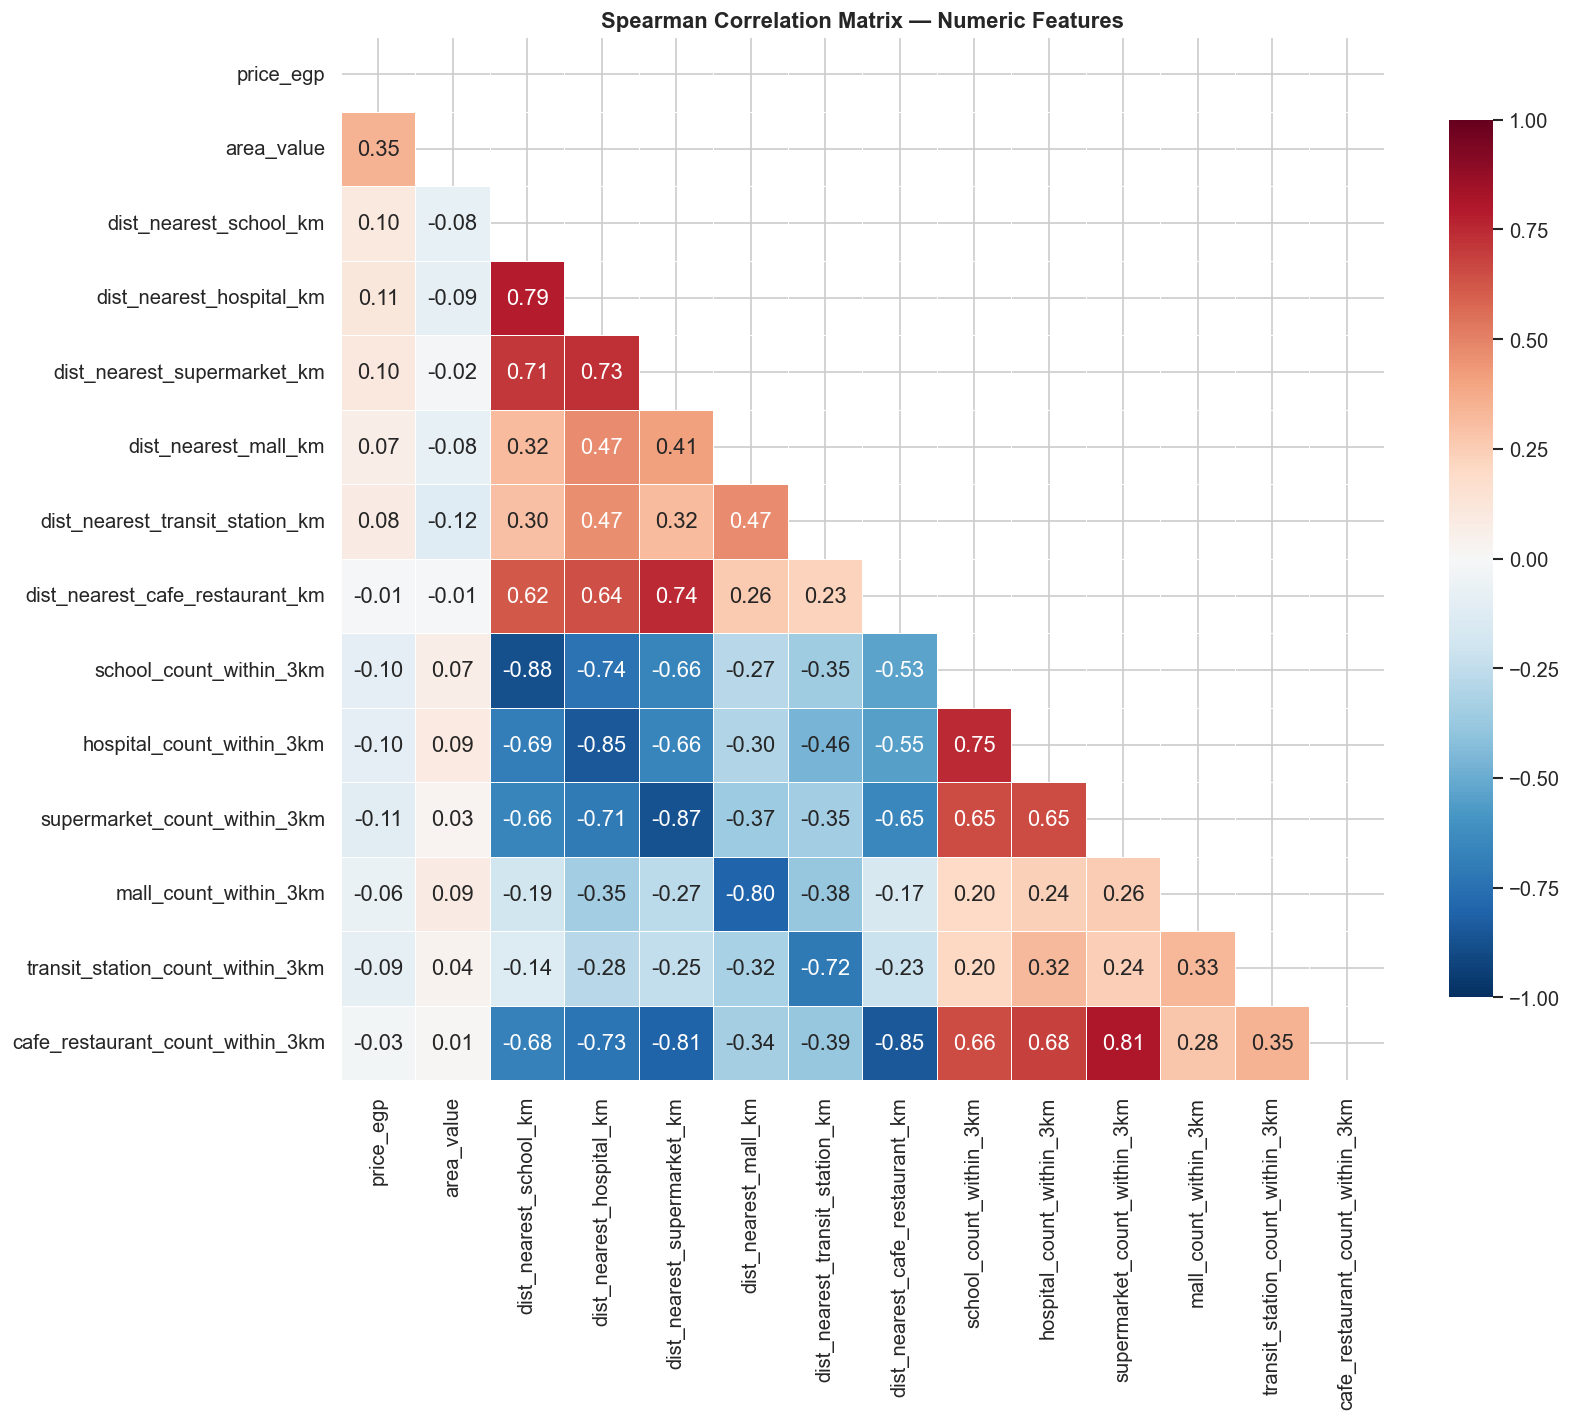

In [46]:
def plot_spearman_correlation_matrix(
    df: pd.DataFrame,
    columns: list[str],
    figsize: tuple[int, int] = (14, 12),
    save_path: Path | None = None,
) -> pd.DataFrame:
    """Compute and plot the Spearman correlation matrix for numeric features.

    Spearman (rank-based) is used because:
    - price_egp and POI features are skewed
    - It captures monotonic (not just linear) relationships
    - It is robust to the outliers that remain after capping

    Note: This matches the Phase 1 validation methodology.

    Args:
        df: Input DataFrame.
        columns: Numeric columns to include.
        figsize: Figure size.
        save_path: Optional save path.

    Returns:
        Spearman correlation matrix as a DataFrame.
    """
    valid_cols = [c for c in columns if c in df.columns]
    corr = df[valid_cols].corr(method="spearman")

    mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        ax=ax, square=True, linewidths=0.3, linecolor="white",
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("Spearman Correlation Matrix — Numeric Features",
                 fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return corr


CORR_COLS = CONTINUOUS_FEATURES + POI_DISTANCE_COLS + POI_COUNT_COLS
corr_matrix = plot_spearman_correlation_matrix(
    df, columns=CORR_COLS,
    save_path=FIGURES_PATH / "13_spearman_correlation_matrix.png",
)

### Correlations with price_egp:

- area_value has the strongest correlation with price among all numeric features
- All POI distances: ρ = 0.06–0.12, extremely weak positive correlations with price. Slightly positive, meaning higher prices correlate weakly with being farther from amenities, reflecting the luxury compound effect.
- All POI counts: ρ = -0.03 to -0.12, tiny negative correlations. More amenities nearby correlates very weakly with lower prices, reflecting that dense urban areas tend to have more affordable housing than sparse suburban compounds.

The key insight: None of the 12 POI features have a strong direct correlation with price (all between -0.12 and +0.12). This means the POI features need to work in combination with city to be useful, their predictive signal is conditional on geographic context.

### The 6 distance features form a strongly intercorrelated block:

This confirms what was noted in Phase 1: properties far from one amenity tend to be far from all amenities. These features are measuring fundamentally the same thing, urban accessibility. 

### The POI Count Cluster

The 6 count features also correlate strongly with each other

Same interpretation, dense urban areas have many of all POI types simultaneously.

### Distance vs Count: The Negative Diagonal 
Every distance feature correlates negatively with every count feature:

The closer you are to amenities (low distance), the more of them exist nearby (high count). These pairs are mostly redundant, each distance feature is almost perfectly predictable from its corresponding count feature.

### Pair Plot of Numeric Features

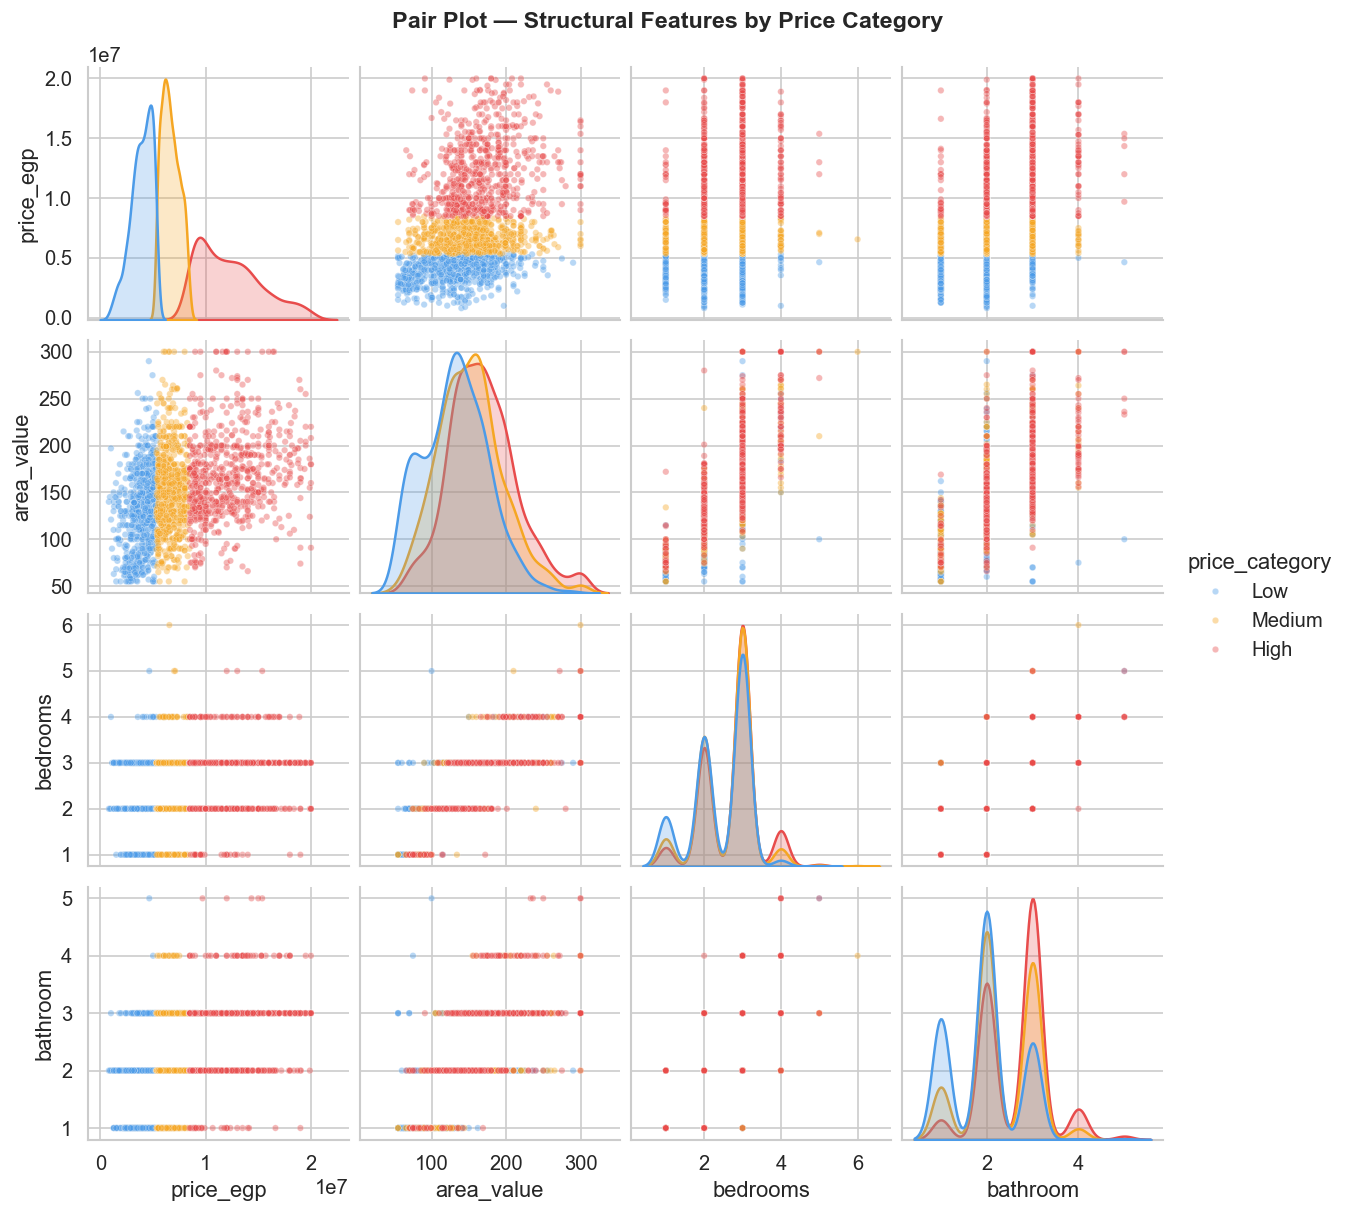

In [47]:
def plot_pairplot_structural(
    df: pd.DataFrame,
    features: list[str],
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    sample_n: int = 2000,
    save_path: Path | None = None,
) -> None:
    """Plot a pair plot for structural features colored by price category.

    Uses a stratified sample for performance.

    Args:
        df: Input DataFrame.
        features: Features to include in the pair plot.
        target_col: Hue variable.
        order: Category order.
        palette: Color palette dict.
        sample_n: Max points to include.
        save_path: Optional save path.
    """
    sample_parts = []
    for _, group in df.groupby(target_col, observed=True):
        sample_parts.append(
            group.sample(n=min(sample_n // 3, len(group)), random_state=42)
        )
    sample = pd.concat(sample_parts, ignore_index=True)

    g = sns.pairplot(
        sample[features + [target_col]],
        hue=target_col, hue_order=order, palette=palette,
        diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15},
        diag_kws={"linewidth": 1.5},
    )
    g.fig.suptitle("Pair Plot — Structural Features by Price Category",
                   fontsize=14, fontweight="bold", y=1.01)

    if save_path:
        g.fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_pairplot_structural(
    df,
    features=["price_egp", "area_value", "bedrooms", "bathroom"],
    target_col=TARGET_COL,
    order=TARGET_ORDER,
    palette=CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "14_pairplot_structural.png",
)

### Diagonal (KDE per tier):

- price_egp diagonal: Three clearly separated KDE peaks, Low peaks around 3–4M (blue), Medium around 6–7M (orange), High has a flatter, wider distribution across 8–22M (red).
  
- area_value diagonal: All three tier KDEs overlap substantially and share almost the same peak (~130–160 sqm).
  
### Off-Diagonal (Scatter plots):
- price_egp vs area_value (row 1, col 2): The three color bands (Low at bottom, Medium middle, High top) are visible but with significant vertical overlap.
  
The pair plot confirms the order of feature usefulness: area_value >> bedrooms ≈ bathrooms for discrimination. 

### Parallel Coordinates Plot for Key Features

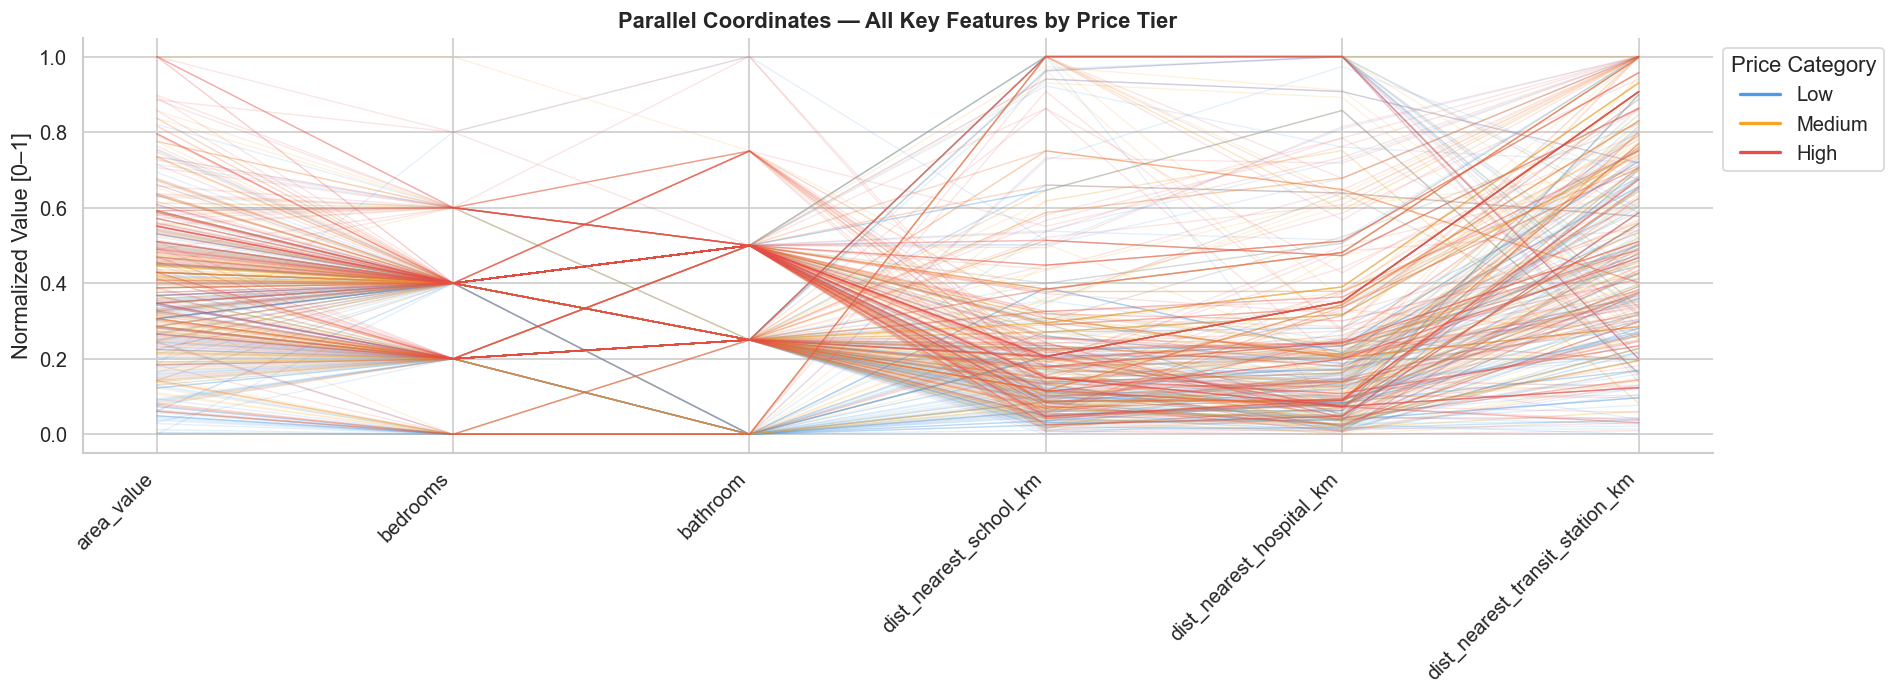

In [48]:
def plot_parallel_coordinates(
    df: pd.DataFrame,
    features: list[str],
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    sample_n: int = 600,
    save_path: Path | None = None,
) -> None:
    """Plot parallel coordinates for multiple features colored by price category.

    Each listing is a line crossing all feature axes. Bundles of similar-colored
    lines reveal tier-specific patterns across all features simultaneously.

    Features are min-max normalized before plotting so all axes are on [0,1].

    Args:
        df: Input DataFrame.
        features: Features to plot as parallel axes.
        target_col: Color variable.
        order: Category order.
        palette: Color palette dict.
        sample_n: Max points per category.
        save_path: Optional save path.
    """
    from matplotlib.lines import Line2D

    sample_parts = []
    for _, group in df.groupby(target_col, observed=True):
        sample_parts.append(
            group.sample(n=min(sample_n // 3, len(group)), random_state=42)
        )
    sample = pd.concat(sample_parts, ignore_index=True)

    valid_features = [f for f in features if f in df.columns]
    plot_data = sample[valid_features + [target_col]].dropna()

    # Min-max normalize each feature to [0, 1] for comparability
    normalized = plot_data[valid_features].copy()
    for col in valid_features:
        col_min, col_max = normalized[col].min(), normalized[col].max()
        if col_max > col_min:
            normalized[col] = (normalized[col] - col_min) / (col_max - col_min)

    fig, ax = plt.subplots(figsize=(16, 6))
    x_positions = range(len(valid_features))

    for _, row in normalized.iterrows():
        cat = plot_data.loc[row.name, target_col]
        color = palette.get(str(cat), "#999999")
        ax.plot(x_positions, row[valid_features].values,
                color=color, alpha=0.15, linewidth=0.8)

    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(valid_features, rotation=45, ha="right")
    ax.set_ylabel("Normalized Value [0–1]")
    ax.set_title("Parallel Coordinates — All Key Features by Price Tier",
                 fontweight="bold")

    legend_elements = [
        Line2D([0], [0], color=palette[c], linewidth=2, label=c)
        for c in order
    ]
    ax.legend(handles=legend_elements, title="Price Category",
              bbox_to_anchor=(1, 1))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


PARALLEL_FEATURES = [
    "area_value", "bedrooms", "bathroom",
    "dist_nearest_school_km", "dist_nearest_hospital_km",
    "dist_nearest_transit_station_km",
    # "school_count_within_3km", "transit_station_count_within_3km",
]

plot_parallel_coordinates(
    df,
    features=PARALLEL_FEATURES,
    target_col=TARGET_COL,
    order=TARGET_ORDER,
    palette=CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "15_parallel_coordinates.png",
)

All 8 features are min-max normalized to [0–1] so they're comparable on the same axis.

area_value axis (leftmost): Lines spread across the full 0–1 range for all three colors, significant mixing.

bedrooms axis: Lines converge toward the middle (0.2–0.4 range, corresponding to 2–3 bedrooms). All three tier colors cluster at the same values, confirming that bedroom count does not separate tiers.

bathrooms axis: Lines fan out more than bedrooms but still show heavy mixing.

dist_nearest_school_km and dist_nearest_hospital_km axes: A dramatic convergence, nearly all lines from all tiers collapse toward 0 (short distances) with only a sparse scatter of long-distance lines. no tier separation at all here.

dist_nearest_transit_station_km axis: More spread than school/hospital. Some tier separation is visible, a concentration of red lines at higher normalized values (farther from transit).

### Bubble Chart Showing Area, Price and Bedrooms

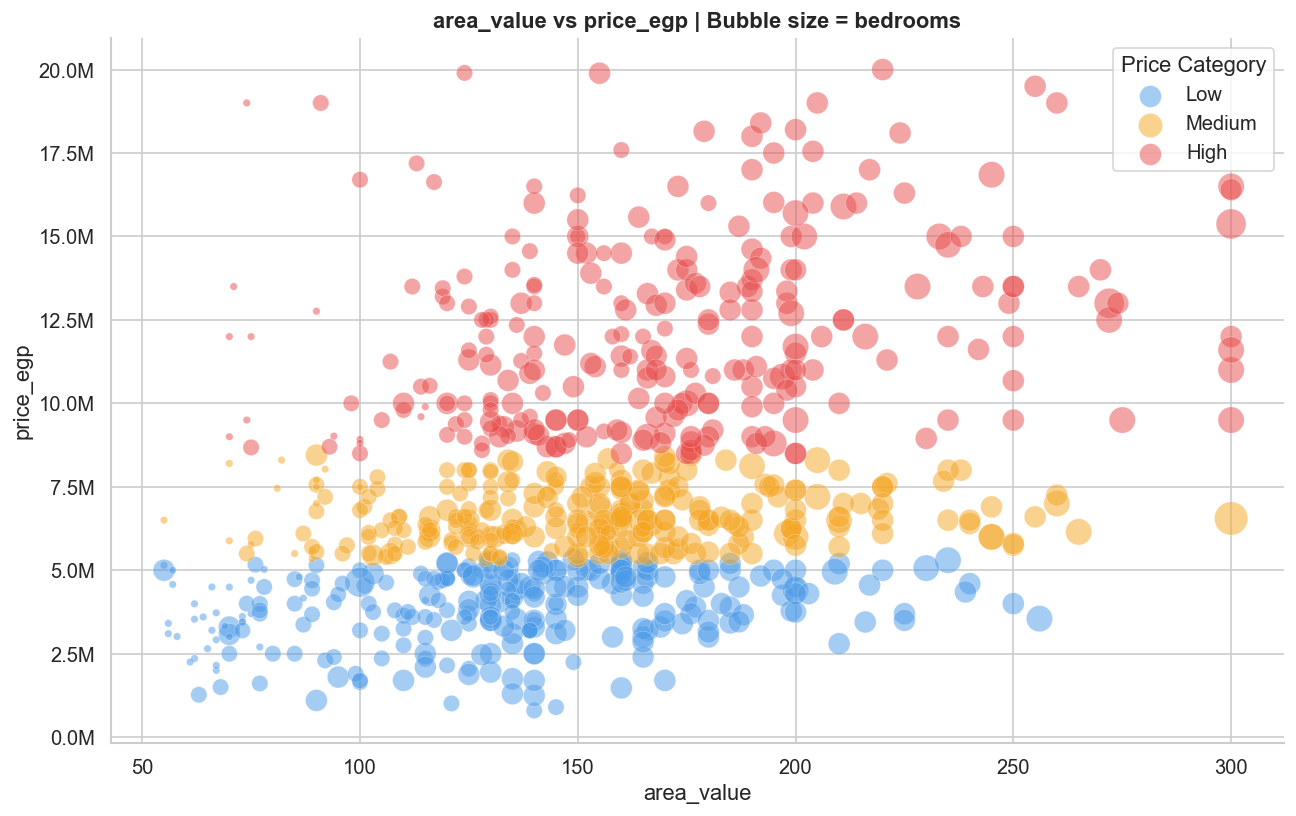

In [49]:
def plot_bubble_chart(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    size_col: str,
    hue_col: str,
    order: list[str],
    palette: dict[str, str],
    sample_n: int = 800,
    save_path: Path | None = None,
) -> None:
    """Plot a bubble chart: x vs y, bubble size = third variable, color = category.

    Args:
        df: Input DataFrame.
        x_col: X-axis continuous feature.
        y_col: Y-axis continuous feature.
        size_col: Feature controlling bubble size.
        hue_col: Target column for color.
        order: Category order.
        palette: Color palette dict.
        sample_n: Max total points.
        save_path: Optional save path.
    """
    sample_parts = []
    for _, group in df.groupby(TARGET_COL, observed=True):
        sample_parts.append(
            group.sample(n=min(sample_n // 3, len(group)), random_state=42)
        )
    sample = pd.concat(sample_parts, ignore_index=True)

    # Normalize size to [20, 400] for visibility
    s_min, s_max = sample[size_col].min(), sample[size_col].max()
    bubble_sizes = 20 + 380 * (sample[size_col] - s_min) / max(s_max - s_min, 1)

    fig, ax = plt.subplots(figsize=(11, 7))
    for cat in order:
        mask = sample[hue_col] == cat
        ax.scatter(
            sample.loc[mask, x_col],
            sample.loc[mask, y_col],
            s=bubble_sizes[mask],
            color=palette[cat],
            alpha=0.5, label=cat, edgecolors="white", linewidth=0.3,
        )

    ax.set_title(f"{x_col} vs {y_col} | Bubble size = {size_col}",
                 fontweight="bold")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M")
    )
    ax.legend(title="Price Category")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_bubble_chart(
    df,
    x_col="area_value", y_col="price_egp", size_col="bedrooms",
    hue_col=TARGET_COL, order=TARGET_ORDER, palette=CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "16_bubble_chart.png",
)

This chart encodes four variables simultaneously: area (x), price (y), bedrooms (bubble size), and price tier (color).

The bubble chart shows that bedroom count adds marginal information beyond area and price tier. However, within the High tier, bedroom count varies widely.


### POI Features vs. Target (Price Category)

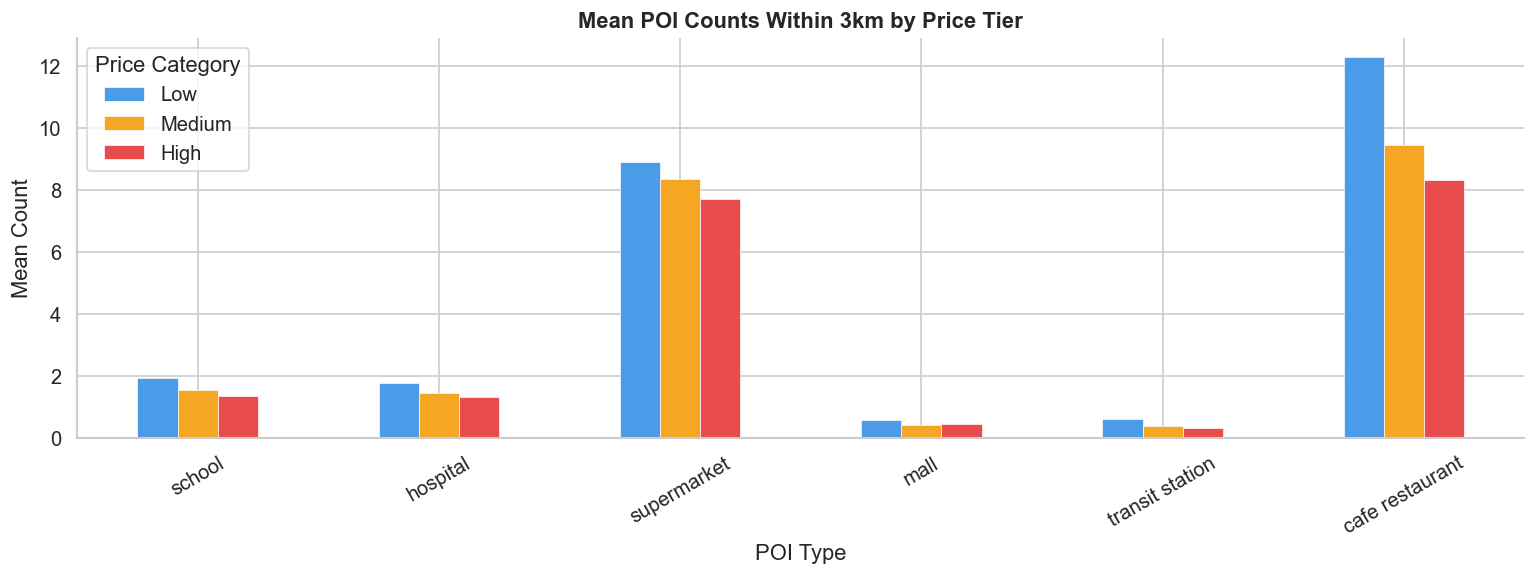

In [50]:
def plot_poi_count_comparison(
    df: pd.DataFrame,
    count_cols: list[str],
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    save_path: Path | None = None,
) -> None:
    """Plot mean POI counts per price tier as a grouped bar chart.

    Args:
        df: Input DataFrame.
        count_cols: POI count column names.
        target_col: Target column.
        order: Category order.
        palette: Color palette.
        save_path: Optional save path.
    """
    means = df.groupby(target_col, observed=True)[count_cols].mean().reindex(order)
    short_names = [c.replace("_count_within_3km", "").replace("_", " ") for c in count_cols]
    means.columns = short_names

    ax = means.T.plot(kind="bar", figsize=(13, 5),
                      color=[palette[c] for c in order],
                      edgecolor="white", linewidth=0.4)
    ax.set_title("Mean POI Counts Within 3km by Price Tier", fontweight="bold")
    ax.set_xlabel("POI Type")
    ax.set_ylabel("Mean Count")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Price Category")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_poi_count_comparison(
    df, POI_COUNT_COLS, TARGET_COL, TARGET_ORDER, CATEGORY_PALETTE,
    save_path=FIGURES_PATH / "20_poi_counts_by_tier.png",
)

Across every single POI type, the bar pattern is the same: Blue (Low) > Orange (Medium) > Red (High). Low-tier listings consistently have more amenities within 3km than High-tier listings, for all 6 POI types.

More urban infrastructure = lower price tier. This reverses the naive assumption that "more amenities = more desirable = more expensive." 

The real estate market reveals the opposite: High-tier listings are in planned, low-density compounds that trade urban accessibility for exclusivity, space, and security. Low-tier listings are in dense urban cores where POIs are abundant and apartments are affordable.

This inverse relationship is crucial for the model. The POI count features signal urban density, and urban density in Egypt correlates with affordability, not luxury.

## Statistical Tests

### One-Way Anova Test to Determine: "Do different cities have different avg prices?"

In [51]:
def run_one_way_anova(
    df: pd.DataFrame,
    numeric_col: str,
    group_col: str,
    alpha: float = ALPHA,
    min_group_size: int = 30,
) -> dict:
    """Run one-way ANOVA to test if a numeric variable's mean differs across groups.

    Pre-conditions checked (from lecture):
    1. Normality per group (Shapiro-Wilk) — for groups with n in [20, 2000]
    2. Homogeneity of variance (Levene's test)

    Args:
        df: Input DataFrame.
        numeric_col: Continuous dependent variable.
        group_col: Categorical grouping variable.
        alpha: Significance level (default 0.05).
        min_group_size: Minimum group size to include in test.

    Returns:
        Dict with F-statistic, p-value, and interpretation.
    """
    groups = {
        cat: grp[numeric_col].dropna().values
        for cat, grp in df.groupby(group_col)
        if len(grp) >= min_group_size
    }

    if len(groups) < 2:
        return {"error": "Fewer than 2 qualifying groups"}

    print(f"\n--- One-Way ANOVA: {numeric_col} across {group_col} ---")
    print(f"Groups included (n >= {min_group_size}): {list(groups.keys())}")

    # Step 1: Normality check (Shapiro-Wilk)
    print("\n1. Normality (Shapiro-Wilk):")
    normality_ok = True
    for cat, vals in groups.items():
        sample = vals[:2000] if len(vals) > 2000 else vals
        stat, p = shapiro(sample)
        ok = p > alpha
        print(f"   {cat}: W={stat:.4f}, p={p:.4f} {'✓' if ok else '✗'}")
        if not ok:
            normality_ok = False

    # Step 2: Homogeneity of variance (Levene's test)
    lev_stat, lev_p = levene(*groups.values())
    variance_ok = lev_p > alpha
    print(f"\n2. Levene's Test: stat={lev_stat:.4f}, p={lev_p:.4f} "
          f"{'✓ Equal variances' if variance_ok else '✗ Unequal variances'}")

    # Step 3: ANOVA
    f_stat, p_val = f_oneway(*groups.values())
    reject = p_val < alpha
    print(f"\n3. One-Way ANOVA:")
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   p-value:     {p_val:.6f}")
    print(f"   Result: {'REJECT H₀' if reject else 'FAIL TO REJECT H₀'} (α={alpha})")

    # Step 4: Post-hoc Tukey HSD if significant
    if reject:
        print("\n4. Post-Hoc Tukey HSD:")
        all_vals   = np.concatenate(list(groups.values()))
        all_labels = np.concatenate([[cat] * len(v) for cat, v in groups.items()])
        tukey = pairwise_tukeyhsd(all_vals, all_labels, alpha=alpha)
        print(tukey.summary())

    return {"F": f_stat, "p": p_val, "reject": reject}


anova_result = run_one_way_anova(df, numeric_col="price_egp", group_col="city")


--- One-Way ANOVA: price_egp across city ---
Groups included (n >= 30): ['Alexandria', 'Cairo', 'Giza', 'Matruh', 'North Coast', 'Red Sea', 'Suez']

1. Normality (Shapiro-Wilk):
   Alexandria: W=0.9669, p=0.4391 ✓
   Cairo: W=0.9319, p=0.0000 ✗
   Giza: W=0.9330, p=0.0000 ✗
   Matruh: W=0.9213, p=0.0000 ✗
   North Coast: W=0.9311, p=0.0000 ✗
   Red Sea: W=0.8905, p=0.0000 ✗
   Suez: W=0.9792, p=0.6149 ✓

2. Levene's Test: stat=15.7029, p=0.0000 ✗ Unequal variances

3. One-Way ANOVA:
   F-statistic: 45.9736
   p-value:     0.000000
   Result: REJECT H₀ (α=0.05)

4. Post-Hoc Tukey HSD:
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
   group1      group2      meandiff   p-adj      lower         upper     reject
-------------------------------------------------------------------------------
 Alexandria       Cairo   -82341.2277    1.0 -2133691.8219  1969009.3666  False
 Alexandria        Giza  -894007.7703 0.8597 -2947684.5999  1159669.0593  False
 Alexand

### Statistical result: F=45.97, p≈0 so there are significant differences exist between cities


### Chi-Square Tests to Determine: "Is there a correlation between price category and completion status or furnished/unfurnished?"


--- Chi-Square Test: furnished × price_category ---
Chi² statistic: 618.4522
Degrees of freedom: 6
p-value: 0.000000
Result: REJECT H₀ (α=0.05)
Cramér's V: 0.1155 → small association


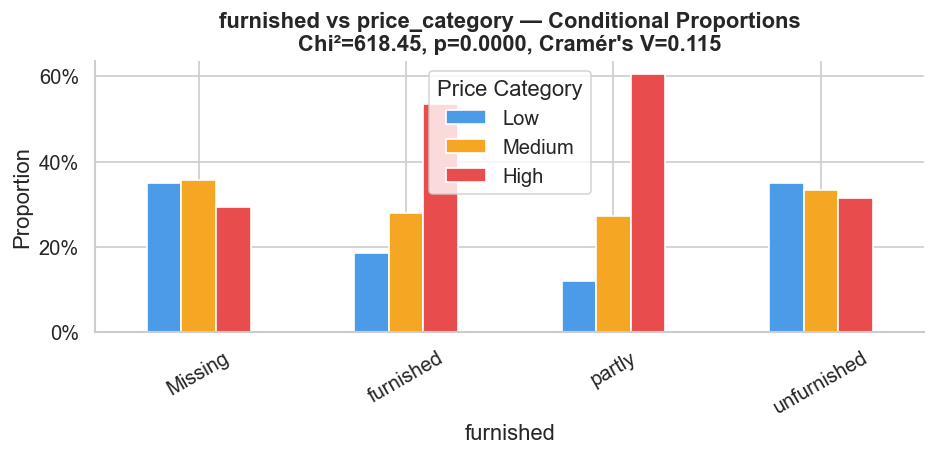


--- Chi-Square Test: completion_status × price_category ---
Chi² statistic: 66.1437
Degrees of freedom: 4
p-value: 0.000000
Result: REJECT H₀ (α=0.05)
Cramér's V: 0.0378 → negligible association


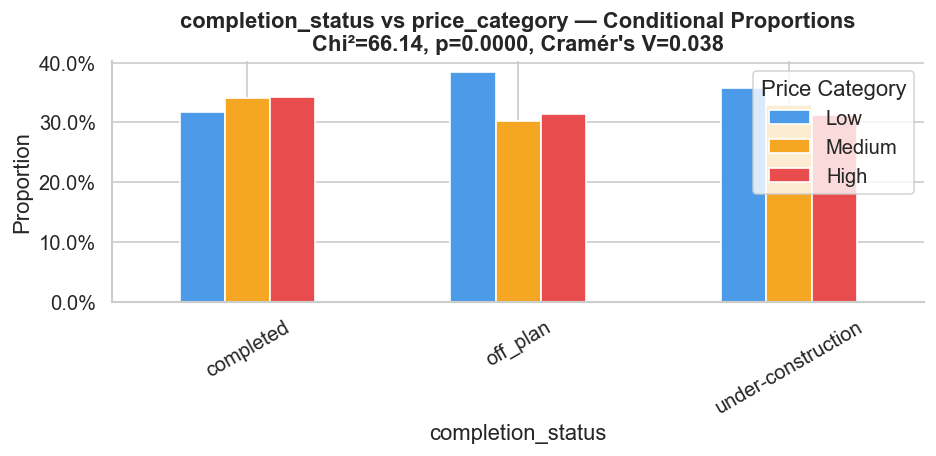

In [52]:
def run_chi_square_independence(
    df: pd.DataFrame,
    row_col: str,
    col_col: str,
    alpha: float = ALPHA,
) -> dict:
    """Run Chi-Square test of independence between two categorical variables.

    Also computes Cramér's V for effect size.

    Args:
        df: Input DataFrame.
        row_col: Row categorical variable.
        col_col: Column categorical variable.
        alpha: Significance level.

    Returns:
        Dict with chi2, p-value, Cramér's V, and interpretation.
    """
    ct = pd.crosstab(df[row_col], df[col_col])
    chi2, p, dof, expected = chi2_contingency(ct)
    reject = p < alpha

    n = ct.values.sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    if cramers_v < 0.1:
        effect = "negligible"
    elif cramers_v < 0.3:
        effect = "small"
    elif cramers_v < 0.5:
        effect = "medium"
    else:
        effect = "large"

    print(f"\n--- Chi-Square Test: {row_col} × {col_col} ---")
    print(f"Chi² statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"p-value: {p:.6f}")
    print(f"Result: {'REJECT H₀' if reject else 'FAIL TO REJECT H₀'} (α={alpha})")
    print(f"Cramér's V: {cramers_v:.4f} → {effect} association")

    # Visualize: bar chart of conditional proportions
    ct_norm = pd.crosstab(df[row_col], df[col_col], normalize="index").reindex(
        columns=TARGET_ORDER, fill_value=0
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    ct_norm.plot(kind="bar", stacked=False, ax=ax,
                 color=[CATEGORY_PALETTE.get(c, "#999") for c in TARGET_ORDER],
                 edgecolor="white")
    ax.set_title(f"{row_col} vs {col_col} — Conditional Proportions\n"
                 f"Chi²={chi2:.2f}, p={p:.4f}, Cramér's V={cramers_v:.3f}",
                 fontweight="bold")
    ax.set_ylabel("Proportion")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Price Category")
    plt.tight_layout()
    plt.savefig(
        FIGURES_PATH / f"21_chi2_{row_col}_vs_{col_col}.png",
        bbox_inches="tight",
    )
    plt.show()

    return {"chi2": chi2, "p": p, "cramers_v": cramers_v, "effect": effect}


chi2_furnished = run_chi_square_independence(df, "furnished", TARGET_COL)
chi2_completion = run_chi_square_independence(df, "completion_status", TARGET_COL)

In [53]:
chi2_results = {
    "furnished × price_category":         chi2_furnished,
    "completion_status × price_category":  chi2_completion,
}

chi2_summary = pd.DataFrame([
    {
        "comparison": k,
        "chi2":       v["chi2"],
        "p_value":    v["p"],
        "cramers_v":  v["cramers_v"],
        "effect":     v["effect"],
        "significant": v["p"] < ALPHA,
    }
    for k, v in chi2_results.items()
])
print("\nChi-Square Test Summary:")
chi2_summary


Chi-Square Test Summary:


,comparison,chi2,p_value,cramers_v,effect,significant
0,furnished × price_category,618.452167,2.438649e-130,0.115462,small,True
1,completion_status × price_category,66.143737,1.477291e-13,0.037760,negligible,True


### Furnished × Price Category
Statistical result: χ²=618.45, p≈0, Cramér's V=0.115 → statistically significant, small association


### Completion Status × Price Category
Statistical result: χ²=66.14, p≈0, Cramér's V=0.038 → statistically significant, but negligible association

### Ranking Features by Correlation with Target

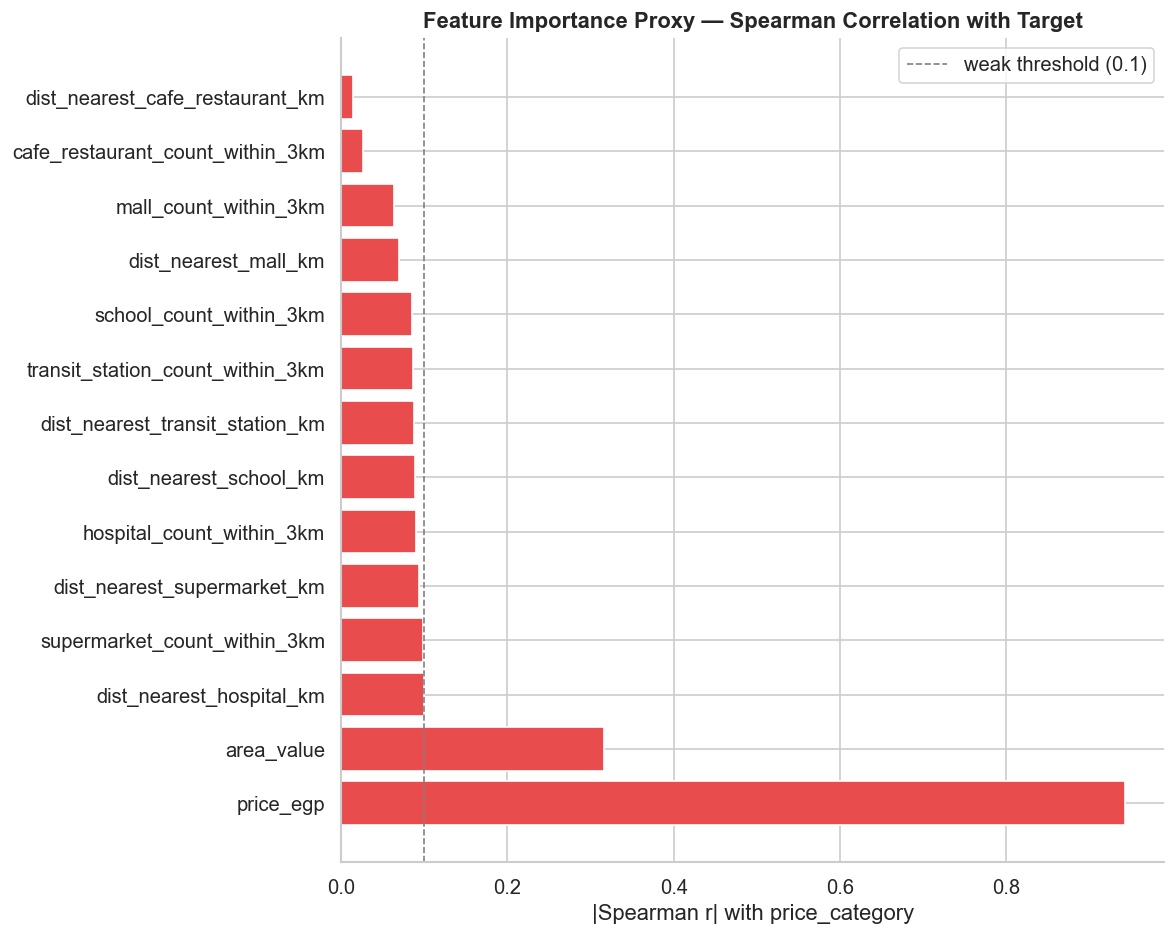

                         feature  spearman_r    abs_r      p_value  significant
                       price_egp    0.942844 0.942844 0.000000e+00         True
                      area_value    0.316321 0.316321 0.000000e+00         True
        dist_nearest_hospital_km    0.100335 0.100335 5.723510e-53         True
    supermarket_count_within_3km   -0.098283 0.098283 6.920335e-51         True
     dist_nearest_supermarket_km    0.093321 0.093321 4.952265e-46         True
       hospital_count_within_3km   -0.089906 0.089906 7.744907e-43         True
          dist_nearest_school_km    0.088437 0.088437 1.684096e-41         True
 dist_nearest_transit_station_km    0.087909 0.087909 5.022115e-41         True
transit_station_count_within_3km   -0.086916 0.086916 3.864881e-40         True
         school_count_within_3km   -0.084877 0.084877 2.369119e-38         True
            dist_nearest_mall_km    0.069180 0.069180 5.179865e-26         True
           mall_count_within_3km   -0.06

In [54]:
def rank_features_by_target_correlation(
    df: pd.DataFrame,
    numeric_features: list[str],
    target_col: str,
    order: list[str],
) -> pd.DataFrame:
    """Rank numeric features by Spearman correlation with the encoded target.

    Encodes price_category ordinally (Low=0, Medium=1, High=2) for correlation.

    Args:
        df: Input DataFrame.
        numeric_features: Numeric features to rank.
        target_col: Target column (categorical).
        order: Category order for encoding.

    Returns:
        DataFrame with features ranked by |correlation| descending.
    """
    target_encoded = df[target_col].map({c: i for i, c in enumerate(order)})
    valid_feats = [f for f in numeric_features if f in df.columns]

    rows = []
    for feat in valid_feats:
        corr, p_val = stats.spearmanr(
            df[feat].fillna(df[feat].median()),
            target_encoded,
            nan_policy="omit",
        )
        rows.append({
            "feature":     feat,
            "spearman_r":  corr,
            "abs_r":       abs(corr),
            "p_value":     p_val,
            "significant": p_val < ALPHA,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("abs_r", ascending=False)
        .reset_index(drop=True)
    )


ALL_NUMERIC = CONTINUOUS_FEATURES + POI_DISTANCE_COLS + POI_COUNT_COLS
feature_ranking = rank_features_by_target_correlation(
    df, ALL_NUMERIC, TARGET_COL, TARGET_ORDER
)

# Bar chart of feature importances
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#E84C4C" if r else "#4C9BE8" for r in feature_ranking["significant"]]
ax.barh(feature_ranking["feature"], feature_ranking["abs_r"], color=colors)
ax.set_xlabel("|Spearman r| with price_category")
ax.set_title("Feature Importance Proxy — Spearman Correlation with Target",
             fontweight="bold")
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1, label="weak threshold (0.1)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "22_feature_importance_proxy.png", bbox_inches="tight")
plt.show()

print(feature_ranking.to_string(index=False))

## Dashboard

C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\2463048256.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target_col, y="area_value", order=order,
C:\Users\hankerz\AppData\Local\Temp\ipykernel_28348\2463048256.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y="price_egp", order=order,


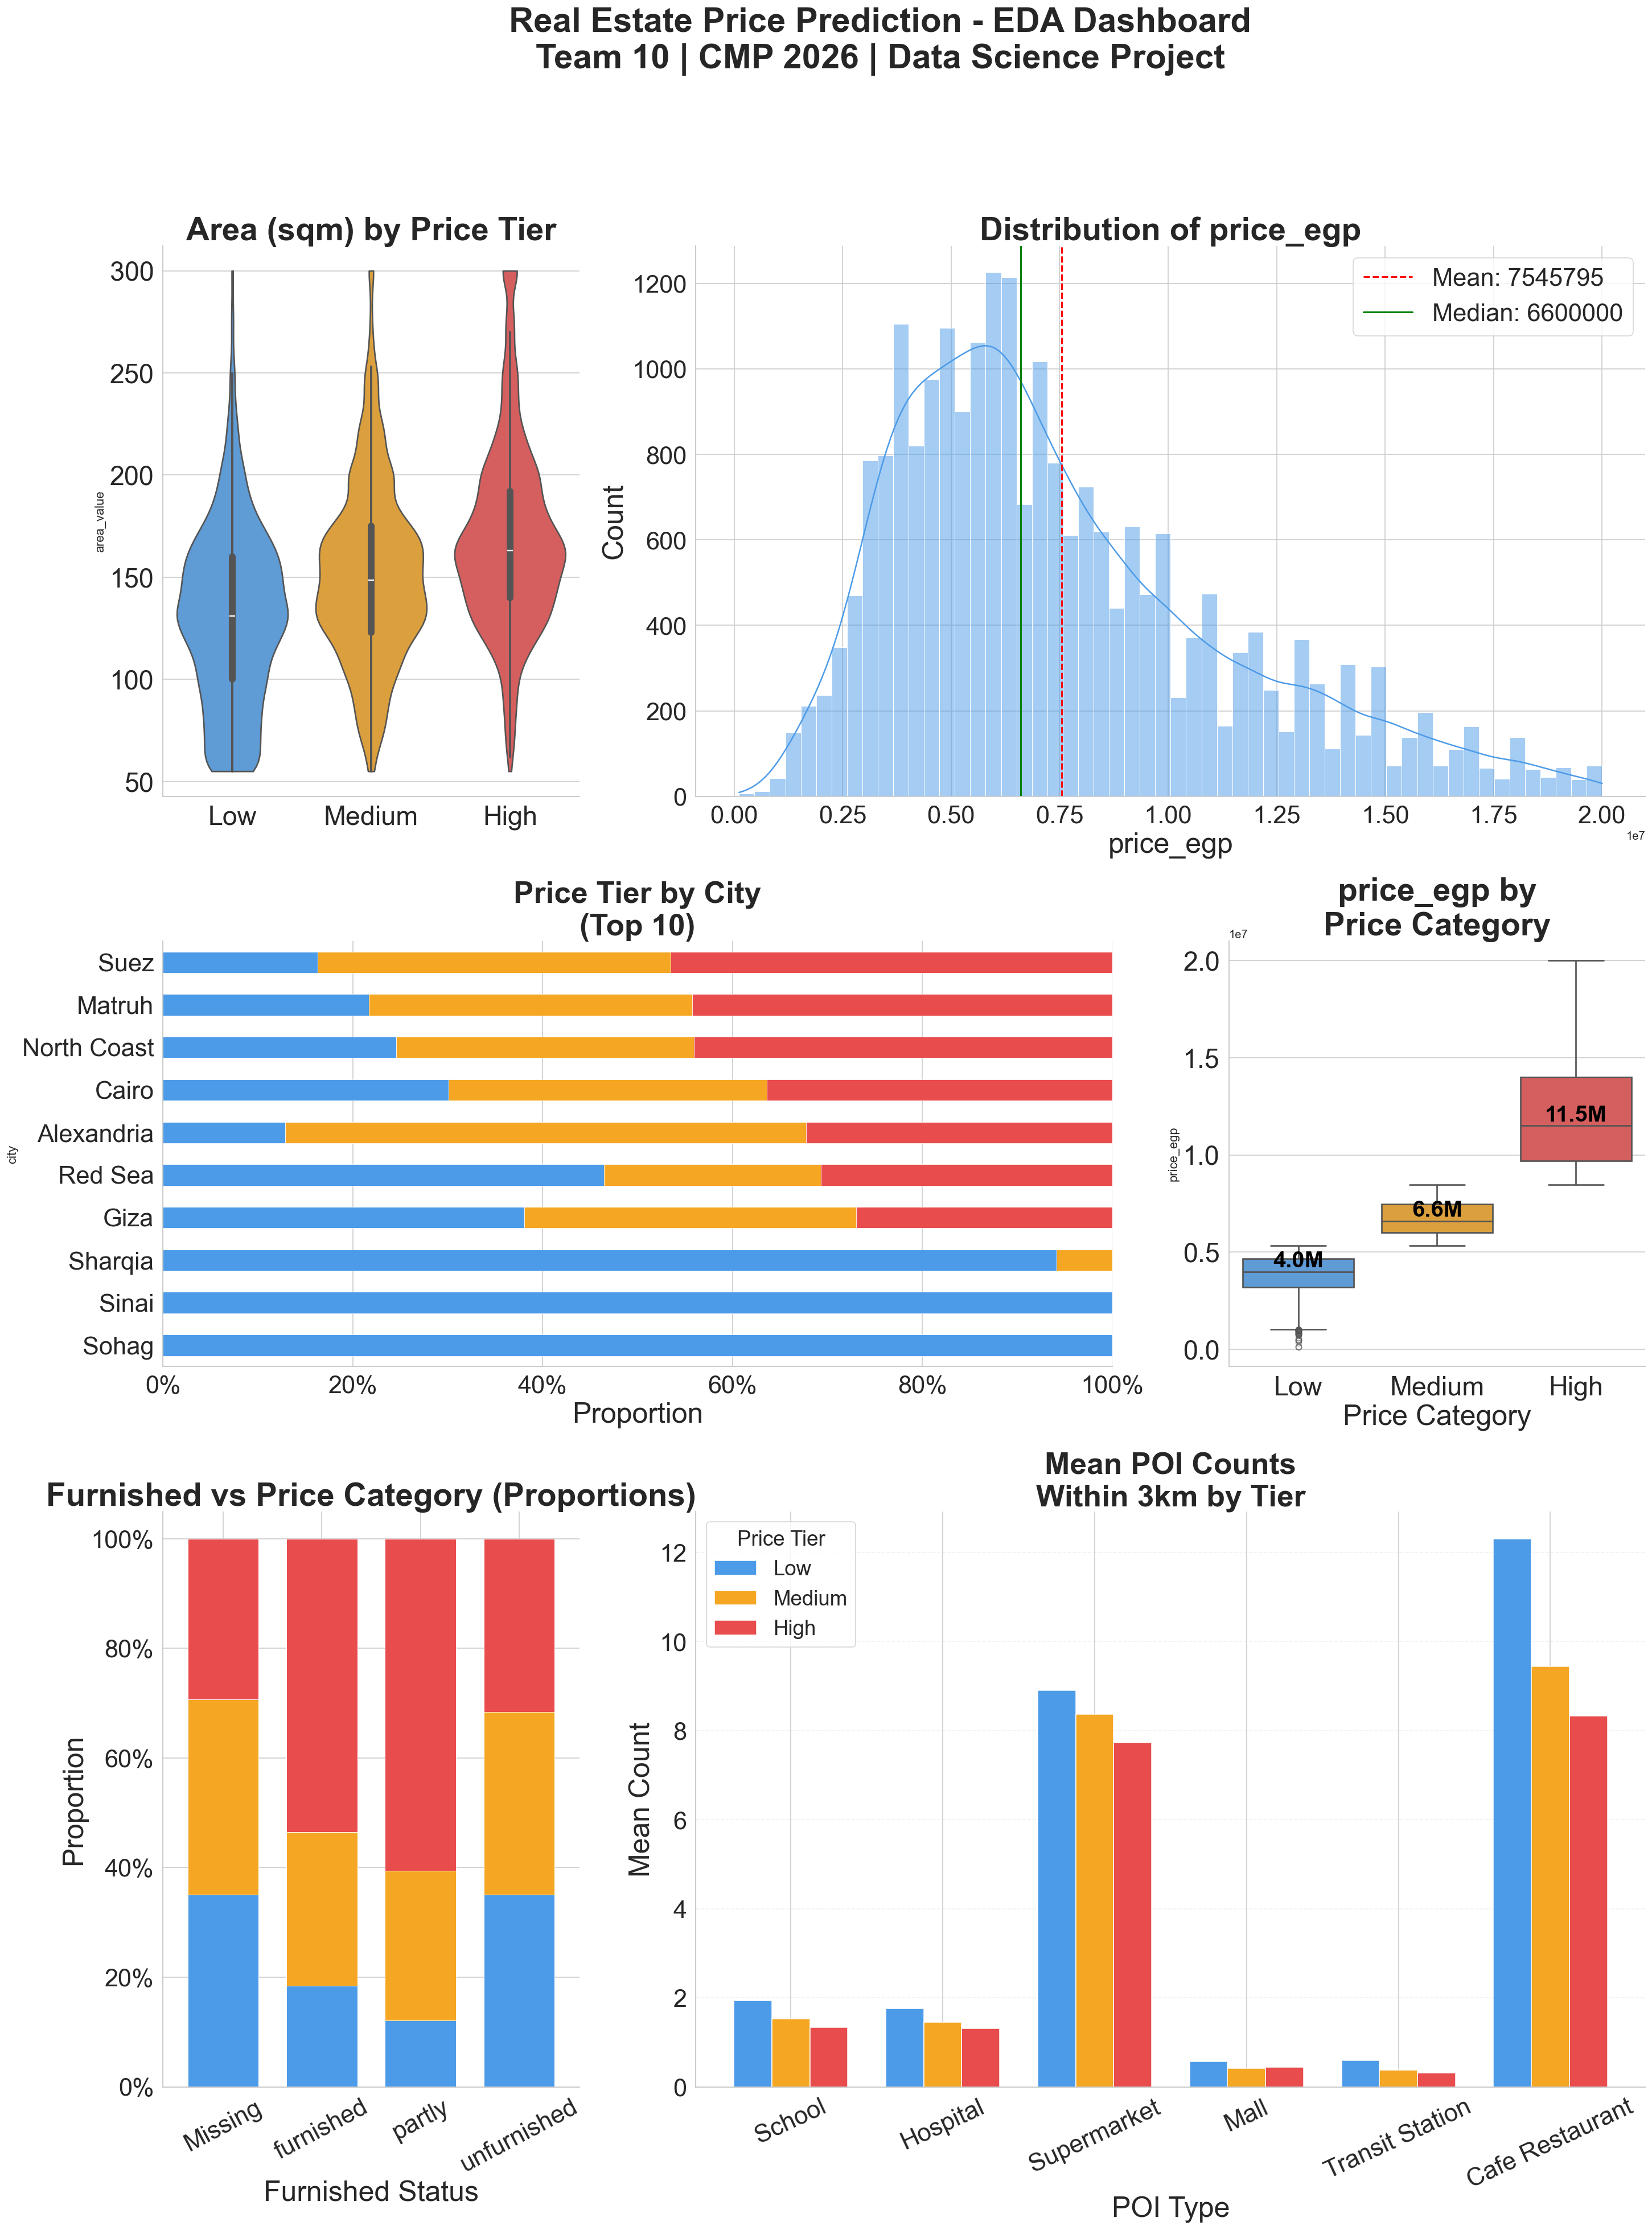

In [ ]:
def build_eda_dashboard(
    df: pd.DataFrame,
    feature_ranking: pd.DataFrame,
    target_col: str,
    order: list[str],
    palette: dict[str, str],
    poi_count_cols: list[str],
    save_path: Path | None = None,
) -> None:
    """Build and save the updated EDA summary dashboard.

    Final tweaks: increase vertical spacing between rows and title, keep proportions.
    """
    fig = plt.figure(figsize=(28, 35))
    fig.patch.set_facecolor("white")

    # increase vertical spacing between rows
    gs = fig.add_gridspec(3, 3, hspace=0.28, wspace=0.28, height_ratios=[1.1, 0.85, 1.15])

    # ROW 1 (now): Area | Histogram | (empty)
    ax_area = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[0, 1:3])

    # ROW 2 (now): Price tier (left, spans 2 cols) | Box Plot (right)
    ax_price_city = fig.add_subplot(gs[1, 0:2])
    ax_box = fig.add_subplot(gs[1, 2])

    # ROW 3: Furnished (left, spans 2 cols) | Mean POI counts (right)
    ax_furnished = fig.add_subplot(gs[2, 0])
    ax_poi = fig.add_subplot(gs[2, 1:3])

    colors = [palette[c] for c in order]

    # Panel: Area by Price Tier (Violin)
    sns.violinplot(data=df, x=target_col, y="area_value", order=order,
                   palette=palette, ax=ax_area, inner="box", linewidth=1.6, cut=0)
    ax_area.set_title("Area (sqm) by Price Tier", fontweight="bold", fontsize=34)
    ax_area.set_xlabel("")
    ax_area.tick_params(axis="both", labelsize=28)

    # Panel: Price distribution histogram
    data = df["price_egp"].dropna()
    iqr = data.quantile(0.75) - data.quantile(0.25)
    bin_width = 2 * iqr / (len(data) ** (1 / 3)) if iqr > 0 else 1
    n_bins = max(10, int((data.max() - data.min()) / bin_width))
    sns.histplot(data, bins=n_bins, kde=True, ax=ax_hist, color="#4C9BE8",
                 edgecolor="white", linewidth=0.6)
    ax_hist.set_title("Distribution of price_egp", fontweight="bold", fontsize=34)
    ax_hist.set_xlabel("price_egp", fontsize=30)
    ax_hist.set_ylabel("Count", fontsize=30)
    ax_hist.axvline(data.mean(), color="red", linestyle="--", linewidth=1.8,
                    label=f"Mean: {data.mean():.0f}")
    ax_hist.axvline(data.median(), color="green", linestyle="-", linewidth=1.8,
                    label=f"Median: {data.median():.0f}")
    ax_hist.legend(fontsize=26)
    ax_hist.tick_params(axis="both", labelsize=26)

    # Panel: Price by Price Category (Box Plot)
    sns.boxplot(data=df, x=target_col, y="price_egp", order=order,
                palette=palette, ax=ax_box, linewidth=1.6,
                flierprops={"marker": "o", "markersize": 6, "alpha": 0.45})
    ax_box.set_title("price_egp by\nPrice Category", fontweight="bold", fontsize=34)
    ax_box.set_xlabel("Price Category", fontsize=30)
    ax_box.tick_params(axis="both", labelsize=28)
    for j, cat in enumerate(order):
        median_val = df[df[target_col] == cat]["price_egp"].median()
        ax_box.text(j, median_val, f"{median_val/1e6:.1f}M",
                    ha="center", va="bottom", fontsize=24, color="black", fontweight="bold")

    # Panel: Price Tier by City (left, wider)
    ct_city = pd.crosstab(df["city"], df[target_col], normalize="index")[order]
    ct_city = ct_city.sort_values("High", ascending=True).tail(10)
    ct_city.plot(kind="barh", stacked=True, ax=ax_price_city,
                 color=colors, edgecolor="white", linewidth=0.45, legend=False)
    ax_price_city.set_title("Price Tier by City\n(Top 10)", fontweight="bold", fontsize=32)
    ax_price_city.set_xlabel("Proportion", fontsize=30)
    ax_price_city.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax_price_city.tick_params(axis="both", labelsize=26)

    # Panel: Furnished vs Price Category (left bottom, wider)
    feat = "furnished"
    top_cats = df[feat].value_counts().head(10).index
    plot_df = df[df[feat].isin(top_cats)]
    ct_norm = pd.crosstab(plot_df[feat], plot_df[target_col], normalize="index")[order]
    ct_norm.plot(kind="bar", stacked=True, ax=ax_furnished,
                 color=[palette[c] for c in order], edgecolor="white",
                 linewidth=0.6, legend=False, width=0.72)
    ax_furnished.set_title("Furnished vs Price Category (Proportions)", fontweight="bold", fontsize=34)
    ax_furnished.set_xlabel("Furnished Status", fontsize=30)
    ax_furnished.set_ylabel("Proportion", fontsize=30)
    ax_furnished.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax_furnished.tick_params(axis="x", rotation=28, labelsize=26)
    ax_furnished.tick_params(axis="y", labelsize=26)

    # Panel: Mean POI Counts (right bottom)
    means = df.groupby(target_col, observed=True)[poi_count_cols].mean().reindex(order)
    short_names = [c.replace("_count_within_3km", "").replace("_", " ").title() for c in poi_count_cols]
    means.columns = short_names
    means.T.plot(kind="bar", ax=ax_poi,
                 color=[palette[c] for c in order], edgecolor="white", linewidth=0.9, width=0.75)
    ax_poi.set_title("Mean POI Counts\nWithin 3km by Tier", fontweight="bold", fontsize=32)
    ax_poi.set_xlabel("POI Type", fontsize=30)
    ax_poi.set_ylabel("Mean Count", fontsize=30)
    ax_poi.tick_params(axis="x", rotation=25, labelsize=26)
    ax_poi.tick_params(axis="y", labelsize=26)
    ax_poi.legend(title="Price Tier", fontsize=22, title_fontsize=22, loc="upper left")
    ax_poi.grid(axis="y", alpha=0.28, linestyle="--")

    # increase top margin so title does not overlap
    fig.subplots_adjust(top=0.88)
    fig.suptitle(
        "Real Estate Price Prediction - EDA Dashboard\n"
        "Team 10 | CMP 2026 | Data Science Project",
        fontsize=36, fontweight="bold", y=0.98,
    )

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


build_eda_dashboard(
    df,
    feature_ranking=feature_ranking,
    target_col=TARGET_COL,
    order=TARGET_ORDER,
    palette=CATEGORY_PALETTE,
    poi_count_cols=POI_COUNT_COLS,
    save_path=FIGURES_PATH / "00_eda_dashboard.png",
)